#Análise de Risco de Defasagem Educacional
#Datathon – Fase 5 | Associação Passos Mágicos

**Curso:** Pós-Tech em Data Analytics  
**Projeto:** Modelo Preditivo de Risco de Defasagem  
**Equipe:**

Fabiana Sampaio Luz (RM362180)

Giovanna Salgado Stancati de Carvalho (RM361545)

Juliana Albuquerque Vitoriano (RM362853)

Lais Stefanie Dias Pereira (RM363219)

---

**Objetivo do Projeto**

Desenvolver uma análise exploratória e um modelo preditivo capaz de identificar alunos com risco de defasagem educacional, utilizando indicadores acadêmicos e psicossociais da base PEDE (2022–2024).

O projeto busca:

- Identificar padrões de defasagem
- Analisar evolução de indicadores ao longo do tempo
- Construir um modelo de Machine Learning
- Gerar probabilidade de risco
- Apoiar decisões pedagógicas estratégicas


# Introdução

Este estudo realiza uma análise longitudinal dos indicadores educacionais e psicossociais
dos alunos atendidos pela Associação Passos Mágicos entre 2022 e 2024.

A investigação integra três dimensões complementares:

1. **Análise Exploratória (EDA)** – identificação de padrões, tendências e correlações.
2. **Inferência Estatística** – validação formal das relações observadas.
3. **Modelagem Preditiva Temporal** – previsão de risco de defasagem futura.

A abordagem adotada conecta evidência quantitativa a implicações estratégicas,
permitindo transformar dados em decisões pedagógicas orientadas por impacto.


#1.Contexto do Desafio

A Associação Passos Mágicos atua há mais de 30 anos na transformação de crianças e jovens em situação de vulnerabilidade social por meio da educação.

A partir dos dados da Pesquisa Extensiva do Desenvolvimento Educacional (PEDE), temos acesso a indicadores multidimensionais como:

- IAN – Índice de Adequação de Nível
- IDA – Índice de Desempenho Acadêmico
- IEG – Índice de Engajamento
- IAA – Índice de Autoavaliação
- IPS – Índice Psicossocial
- IPP – Índice Psicopedagógico
- IPV – Índice de Ponto de Virada
- INDE – Índice Global do Aluno

O desafio é antecipar o risco de defasagem antes que ele ocorra.


In [185]:
# Bibliotecas

# Manipulação de Dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelagem
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from xgboost import XGBClassifier

# Métricas e inspeção
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    r2_score,
    mean_absolute_error,
    precision_recall_curve
)
from sklearn.inspection import permutation_importance

# Estatística
from scipy.stats import wilcoxon, spearmanr, ttest_ind, kruskal
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Outros
import shap
import joblib

# Configurações Globais
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 2.Carregamento da Base de Dados

A base utilizada corresponde aos dados da PEDE referentes aos anos de 2022, 2023 e 2024.

In [186]:
# Carrega PEDE 2022/2023/2024 da URL, adiciona coluna ANO e exibe head + dimensões.

# Carregamento da base
file_path = "https://raw.githubusercontent.com/LaisStefanieDiasPereira/datathon_fase5/ff99396d7501320e7fb9c29cb3a415fa226fd2c8/data/Base%202024/BASE%20DE%20DADOS%20PEDE%202024%20-%20DATATHON%20(2).xlsx"

df_2022 = pd.read_excel(file_path, sheet_name="PEDE2022")
df_2023 = pd.read_excel(file_path, sheet_name="PEDE2023")
df_2024 = pd.read_excel(file_path, sheet_name="PEDE2024")

df_2022["ANO"] = 2022
df_2023["ANO"] = 2023
df_2024["ANO"] = 2024


# Visualização inicial
display(df_2022.head())
display(df_2023.head())
display(df_2024.head())
print(f"Dimensão da base: {df_2022.shape[0]} linhas e {df_2022.shape[1]} colunas")
print(f"Dimensão da base: {df_2023.shape[0]} linhas e {df_2023.shape[1]} colunas")
print(f"Dimensão da base: {df_2024.shape[0]} linhas e {df_2024.shape[1]} colunas")

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,ANO
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022


,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1,ANO
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,...,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023
1,RA-862,ALFA,8.22120,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,...,NaN,8.585,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN,2023
2,RA-863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7,Masculino,2023,...,NaN,6.260,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023
3,RA-864,ALFA,7.03400,Ametista,ALFA A - G0/G1,Aluno-864,2015-12-03 00:00:00,1900-01-08 00:00:00,Feminino,2023,...,NaN,8.500,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023
4,RA-865,ALFA,8.15520,Topázio,ALFA A - G0/G1,Aluno-865,11/13/2014,8,Masculino,2023,...,NaN,7.915,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1,ANO
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,...,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando,2024
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,...,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando,2024
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,...,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando,2024
3,RA-868,ALFA,7.156367,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,...,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando,2024
4,RA-1278,ALFA,5.4442,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,...,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando,2024


Dimensão da base: 860 linhas e 43 colunas
Dimensão da base: 1014 linhas e 49 colunas
Dimensão da base: 1156 linhas e 51 colunas


In [187]:
# Colunas da base 2022.
print(df_2022.columns)

Index(['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero',
       'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21',
       'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3',
       'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA',
       'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN',
       'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV',
       'ANO'],
      dtype='object')


In [188]:
# Colunas da base 2023.
print(df_2023.columns)

Index(['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso',
       'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23',
       'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3',
       'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia',
       'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA',
       'Destaque IPV', 'Destaque IPV.1', 'ANO'],
      dtype='object')


In [189]:
# Colunas da base 2024.
print(df_2024.columns)

Index(['RA', 'Fase', 'INDE 2024', 'Pedra 2024', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso',
       'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23',
       'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Avaliador4',
       'Avaliador5', 'Avaliador6', 'IAA', 'IEG', 'IPS', 'IPP',
       'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV',
       'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA',
       'Destaque IPV', 'Escola', 'Ativo/ Inativo', 'Ativo/ Inativo.1', 'ANO'],
      dtype='object')


In [190]:
# Resumo da base 2022 (tipos e não nulos).
df_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    object 
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    object 
 3   Nome                   860 non-null    object 
 4   Ano nasc               860 non-null    int64  
 5   Idade 22               860 non-null    int64  
 6   Gênero                 860 non-null    object 
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    object 
 9   Pedra 20               323 non-null    object 
 10  Pedra 21               462 non-null    object 
 11  Pedra 22               860 non-null    object 
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 14  Cf                     860 non-null    int64  
 15  Ct    

In [191]:
# Resumo da base 2023 (tipos e não nulos).
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     1014 non-null   object 
 1   Fase                   1014 non-null   object 
 2   INDE 2023              931 non-null    float64
 3   Pedra 2023             931 non-null    object 
 4   Turma                  1014 non-null   object 
 5   Nome Anonimizado       1014 non-null   object 
 6   Data de Nasc           1014 non-null   object 
 7   Idade                  1014 non-null   object 
 8   Gênero                 1014 non-null   object 
 9   Ano ingresso           1014 non-null   int64  
 10  Instituição de ensino  1014 non-null   object 
 11  Pedra 20               240 non-null    object 
 12  Pedra 21               335 non-null    object 
 13  Pedra 22               600 non-null    object 
 14  Pedra 23               0 non-null      float64
 15  INDE

In [192]:
# Resumo da base 2024 (tipos e não nulos).
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1156 non-null   object        
 1   Fase                   1156 non-null   object        
 2   INDE 2024              1092 non-null   object        
 3   Pedra 2024             1092 non-null   object        
 4   Turma                  1156 non-null   object        
 5   Nome Anonimizado       1156 non-null   object        
 6   Data de Nasc           1156 non-null   datetime64[ns]
 7   Idade                  1156 non-null   int64         
 8   Gênero                 1156 non-null   object        
 9   Ano ingresso           1156 non-null   int64         
 10  Instituição de ensino  1155 non-null   object        
 11  Pedra 20               191 non-null    object        
 12  Pedra 21               264 non-null    object        
 13  Ped

In [193]:
# Estatísticas descritivas 2022.
df_2022.describe()

,Fase,Ano nasc,Idade 22,Ano ingresso,INDE 22,Cg,Cf,Ct,Nº Av,IAA,IEG,IPS,IDA,Matem,Portug,Inglês,IPV,IAN,Defas,ANO
count,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,858.000000,858.000000,283.000000,860.000000,860.000000,860.000000,860.0
mean,2.098837,2009.861628,12.138372,2020.496512,7.036176,430.516279,75.519767,6.598837,3.054651,8.274419,7.891163,6.905000,6.092907,5.806876,6.320979,5.881272,7.253642,6.424419,-0.943023,2022.0
std,1.788789,2.771998,2.771998,1.790217,1.017773,248.432761,52.312670,3.975858,0.775371,2.064935,1.638340,1.070707,2.046209,2.414215,2.080364,2.957315,1.093383,2.389609,0.845593,0.0
min,0.000000,2001.000000,7.000000,2016.000000,3.032000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,2.500000,0.000000,0.000000,0.000000,0.000000,2.500000,2.500000,-5.000000,2022.0
25%,1.000000,2008.000000,10.000000,2019.000000,6.485500,215.750000,30.000000,3.000000,2.000000,7.900000,7.000000,6.300000,4.800000,4.300000,5.200000,3.500000,6.722000,5.000000,-1.000000,2022.0
50%,2.000000,2010.000000,12.000000,2021.000000,7.197000,430.500000,67.000000,6.000000,3.000000,8.800000,8.300000,7.500000,6.300000,6.000000,6.700000,6.300000,7.333000,5.000000,-1.000000,2022.0
75%,3.000000,2012.000000,14.000000,2022.000000,7.751250,645.250000,118.000000,9.000000,4.000000,9.500000,9.100000,7.500000,7.600000,7.800000,7.800000,8.500000,7.917000,10.000000,0.000000,2022.0
max,7.000000,2015.000000,21.000000,2022.000000,9.442000,862.000000,192.000000,18.000000,4.000000,10.000000,10.000000,10.000000,9.900000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,2022.0


In [194]:
# Estatísticas descritivas 2023.
df_2023.describe()

,INDE 2023,Ano ingresso,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Rec Av1,...,Indicado,Atingiu PV,IPV,IAN,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1,ANO
count,931.000000,1014.000000,0.0,600.000000,0.0,0.0,0.0,0.0,938.000000,0.0,...,0.0,0.0,938.000000,1014.000000,1014.000000,0.0,0.0,0.0,0.0,1014.0
mean,7.342309,2021.378698,NaN,7.262788,NaN,NaN,NaN,NaN,3.109808,NaN,...,NaN,NaN,8.027897,7.243590,-0.654832,NaN,NaN,NaN,NaN,2023.0
std,0.901757,1.873750,NaN,0.895774,NaN,NaN,NaN,NaN,0.768712,NaN,...,NaN,NaN,0.945427,2.539585,0.821233,NaN,NaN,NaN,NaN,0.0
min,3.745542,2016.000000,NaN,3.700000,NaN,NaN,NaN,NaN,2.000000,NaN,...,NaN,NaN,3.320000,2.500000,-4.000000,NaN,NaN,NaN,NaN,2023.0
25%,6.724150,2021.000000,NaN,6.740250,NaN,NaN,NaN,NaN,3.000000,NaN,...,NaN,NaN,7.462500,5.000000,-1.000000,NaN,NaN,NaN,NaN,2023.0
50%,7.408033,2022.000000,NaN,7.402500,NaN,NaN,NaN,NaN,3.000000,NaN,...,NaN,NaN,8.045000,5.000000,-1.000000,NaN,NaN,NaN,NaN,2023.0
75%,7.996083,2023.000000,NaN,7.903500,NaN,NaN,NaN,NaN,4.000000,NaN,...,NaN,NaN,8.668750,10.000000,0.000000,NaN,NaN,NaN,NaN,2023.0
max,9.371200,2023.000000,NaN,9.442000,NaN,NaN,NaN,NaN,4.000000,NaN,...,NaN,NaN,10.010000,10.000000,2.000000,NaN,NaN,NaN,NaN,2023.0


In [195]:
# Estatísticas descritivas 2024.
df_2024.describe()

,Data de Nasc,Idade,Ano ingresso,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Rec Av1,...,Ing,Indicado,Atingiu PV,IPV,IAN,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,ANO
count,1156,1156.000000,1156.000000,472.000000,690.000000,0.0,0.0,0.0,1156.000000,0.0,...,474.000000,0.0,0.0,1054.000000,1156.000000,1156.000000,0.0,0.0,0.0,1156.0
mean,2011-05-10 06:46:14.740484352,12.987889,2022.519896,7.368276,7.455472,NaN,NaN,NaN,2.951557,NaN,...,6.595886,NaN,NaN,7.354268,7.683824,-0.409170,NaN,NaN,NaN,2024.0
min,1996-12-08 02:00:00,7.000000,2021.000000,3.031806,4.406458,NaN,NaN,NaN,0.000000,NaN,...,0.000000,NaN,NaN,2.943333,2.500000,-3.000000,NaN,NaN,NaN,2024.0
25%,2009-02-28 18:00:00,10.000000,2021.000000,6.890881,6.862402,NaN,NaN,NaN,2.000000,NaN,...,5.000000,NaN,NaN,6.790625,5.000000,-1.000000,NaN,NaN,NaN,2024.0
50%,2012-01-07 00:00:00,12.000000,2023.000000,7.475431,7.559046,NaN,NaN,NaN,3.000000,NaN,...,7.000000,NaN,NaN,7.500000,10.000000,0.000000,NaN,NaN,NaN,2024.0
75%,2014-02-06 06:00:00,15.000000,2024.000000,7.981160,8.048758,NaN,NaN,NaN,4.000000,NaN,...,9.000000,NaN,NaN,8.085000,10.000000,0.000000,NaN,NaN,NaN,2024.0
max,2017-06-02 00:00:00,27.000000,2024.000000,9.441522,9.371200,NaN,NaN,NaN,6.000000,NaN,...,10.000000,NaN,NaN,9.760000,10.000000,3.000000,NaN,NaN,NaN,2024.0
std,NaN,3.584699,1.204804,0.861821,0.850390,NaN,NaN,NaN,1.397985,NaN,...,2.876249,NaN,NaN,1.048541,2.504055,0.850497,NaN,NaN,NaN,0.0


# 3.Tratamento e Preparação dos Dados

##**3.1 Estratégia adotada:**
- Remoção de colunas irrelevantes
- Imputação de valores quando necessário

In [196]:
# Padroniza nomes de colunas entre os três anos (ex.: INDE, PEDRA, DEFASAGEM).
map_2022 = {
    "INDE 22": "INDE",
    "Pedra 22": "PEDRA",
    "Atingiu PV": "PONTO_VIRADA",
    "Defas": "DEFASAGEM",
    "Ano ingresso": "ANO_INGRESSO"
}

map_2023 = {
    "INDE 2023": "INDE",
    "Pedra 2023": "PEDRA",
    "Atingiu PV": "PONTO_VIRADA",
    "Defasagem": "DEFASAGEM",
    "Ano ingresso": "ANO_INGRESSO"
}

map_2024 = {
    "INDE 2024": "INDE",
    "Pedra 2024": "PEDRA",
    "Atingiu PV": "PONTO_VIRADA",
    "Defasagem": "DEFASAGEM",
    "Ano ingresso": "ANO_INGRESSO"
}

In [197]:
# Aplica o renomeamento em cada base.
df_2022 = df_2022.rename(columns=map_2022)
df_2023 = df_2023.rename(columns=map_2023)
df_2024 = df_2024.rename(columns=map_2024)

In [198]:
# Mantém só colunas principais; cria coluna com NaN se faltar em algum ano; filtra bases.
colunas_principais = [
    "RA",
    "IAN", "IDA", "IEG", "IAA",
    "IPS", "IPP", "IPV",
    "INDE", "PEDRA", "PONTO_VIRADA",
    "ANO_INGRESSO"
]

for col in colunas_principais:
    if col not in df_2022.columns:
        df_2022[col] = np.nan

    if col not in df_2023.columns:
        df_2023[col] = np.nan

    if col not in df_2024.columns:
        df_2024[col] = np.nan

df_2022 = df_2022[colunas_principais + ["ANO"]]
df_2023 = df_2023[colunas_principais + ["ANO"]]
df_2024 = df_2024[colunas_principais + ["ANO"]]

In [199]:
# Concatena 2022, 2023 e 2024 em um único DataFrame (df_total).
df_total = pd.concat([df_2022, df_2023, df_2024])

In [200]:
df_total.head()

,RA,IAN,IDA,IEG,IAA,IPS,IPP,IPV,INDE,PEDRA,PONTO_VIRADA,ANO_INGRESSO,ANO
0,RA-1,5.0,4.0,4.1,8.3,5.6,NaN,7.278,5.783,Quartzo,Não,2016,2022
1,RA-2,10.0,6.8,5.2,8.8,6.3,NaN,6.778,7.055,Ametista,Não,2017,2022
2,RA-3,10.0,5.6,7.9,0.0,5.6,NaN,7.556,6.591,Ágata,Não,2016,2022
3,RA-4,10.0,5.0,4.5,8.8,5.6,NaN,5.278,5.951,Quartzo,Não,2017,2022
4,RA-5,10.0,5.2,8.6,7.9,5.6,NaN,7.389,7.427,Ametista,Não,2016,2022


In [201]:
df_total.tail()

,RA,IAN,IDA,IEG,IAA,IPS,IPP,IPV,INDE,PEDRA,PONTO_VIRADA,ANO_INGRESSO,ANO
1151,RA-1658,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
1152,RA-1659,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
1153,RA-1252,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
1154,RA-1660,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
1155,RA-1661,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024


In [202]:
df_total.describe()

,IAN,IDA,IEG,IAA,IPS,IPP,IPV,ANO_INGRESSO,ANO
count,3030.000000,2852.000000,2954.000000,2865.000000,2859.000000,1992.000000,2852.000000,3030.000000,3030.00000
mean,7.179043,6.375964,7.945696,7.918225,6.287129,7.555203,7.545476,2021.563696,2023.09769
std,2.535266,1.956637,2.152281,2.626209,1.792491,0.938990,1.084347,1.822171,0.80995
min,2.500000,0.000000,0.000000,0.000000,2.500000,2.500000,2.500000,2016.000000,2022.00000
25%,5.000000,5.100000,7.300000,7.900000,5.020000,7.083333,6.984000,2021.000000,2022.00000
50%,5.000000,6.666667,8.600000,8.751000,7.500000,7.500000,7.583000,2022.000000,2023.00000
75%,10.000000,7.833333,9.400000,9.500000,7.510000,8.125000,8.255000,2023.000000,2024.00000
max,10.000000,10.000000,10.000000,10.002000,10.000000,10.000000,10.010000,2024.000000,2024.00000


In [203]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3030 entries, 0 to 1155
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RA            3030 non-null   object 
 1   IAN           3030 non-null   float64
 2   IDA           2852 non-null   float64
 3   IEG           2954 non-null   float64
 4   IAA           2865 non-null   float64
 5   IPS           2859 non-null   float64
 6   IPP           1992 non-null   float64
 7   IPV           2852 non-null   float64
 8   INDE          2883 non-null   object 
 9   PEDRA         2883 non-null   object 
 10  PONTO_VIRADA  860 non-null    object 
 11  ANO_INGRESSO  3030 non-null   int64  
 12  ANO           3030 non-null   int64  
dtypes: float64(7), int64(2), object(4)
memory usage: 331.4+ KB


In [204]:
# Contagem de NaN por coluna (ordem decrescente).
df_total.isnull().sum().sort_values(ascending=False)

PONTO_VIRADA    2170
IPP             1038
IPV              178
IDA              178
IPS              171
IAA              165
INDE             147
PEDRA            147
IEG               76
IAN                0
RA                 0
ANO_INGRESSO       0
ANO                0
dtype: int64

In [205]:
# Dimensões (linhas, colunas) de df_total.
df_total.shape

(3030, 13)

In [276]:
# Formato largo: uma linha por RA, colunas por ano (ex.: IAN_2022, IAN_2023).
df_wide = (
    df_total
    .pivot(index="RA", columns="ANO", 
           values=["IAN","IDA","IEG","IAA","IPS","IPP","IPV","INDE",
                   "PEDRA","PONTO_VIRADA","ANO_INGRESSO"])
)

# Achata MultiIndex das colunas
df_wide.columns = [f"{col[0]}_{col[1]}" for col in df_wide.columns]
df_wide = df_wide.reset_index()

In [277]:
# Garantir que as colunas de “df_wide” sejam achatadas (transformadas em um único nível) caso estejam em formato **MultiIndex**.

if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

# Queda de IDA (2023 - 2022).
df_wide["queda_IDA"] = df_wide["IDA_2023"] - df_wide["IDA_2022"]

# Target risco_defasagem (IAN<5.5, queda_IDA<-0.5 ou IEG e IPS<6).
df_wide["risco_defasagem"] = (
    (df_wide["IAN_2022"] < 5.5) |
    (df_wide["queda_IDA"] < -0.5) |
    ((df_wide["IEG_2022"] < 6) & (df_wide["IPS_2022"] < 6))
).astype(int)

# Features (sem IPP_2022, só NaN em 2022).

features = ["IDA_2022","IEG_2022","IPS_2022","IAA_2022","queda_IDA"]
X = df_wide[features]
y = df_wide["risco_defasagem"]

## **3.2 Separação dos Dados**

Utilizamos estratificação para preservar a proporção da variável target.

In [278]:
features = [
    "IDA_2022",  # Desempenho acadêmico médio do aluno em 2022
    "IEG_2022",  # Grau de engajamento nas atividades
    "IPS_2022",  # Indicador psicossocial (aspectos emocionais e sociais)
    "IPP_2022",  # Indicador psicopedagógico
    "IAA_2022",  # Autoavaliação do aluno
    "IPV_2022",  # Indicador de ponto de virada
    "IAN_2022"   # Adequação ao nível (defasagem)
]

df_model = df_wide[features].copy()

In [279]:
# X, y e divisão 80/20 (treino/teste) com estratificação.
features = ["IDA_2022","IEG_2022","IPS_2022","IAA_2022","queda_IDA"]
X = df_wide[features]
y = df_wide["risco_defasagem"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [280]:
# Pipeline: imputer (média) → scaler → MLP. Treina e prediz no teste.
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='mean')),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(hidden_layer_sizes=(100,50),
                            max_iter=500,
                            random_state=42))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

In [281]:
# Relatório de classificação e ROC-AUC.
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       200
           1       0.75      0.80      0.78       133

    accuracy                           0.82       333
   macro avg       0.81      0.81      0.81       333
weighted avg       0.82      0.82      0.82       333

ROC-AUC: 0.9192105263157895


##**3.3 Avaliação do Modelo**

In [282]:
# Redefine X, y e split para consistência com o pipeline (mesmas features).

features_for_pipeline = ["IDA_2022","IEG_2022","IPS_2022","IAA_2022","queda_IDA"]
X_consistent = df_wide[features_for_pipeline]
y_consistent = df_wide["risco_defasagem"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_consistent,
    y_consistent,
    test_size=0.2,
    stratify=y_consistent,
    random_state=42
)

# Predição no conjunto de teste consistente.

y_pred = pipeline.predict(X_test_p)

print("Accuracy:", accuracy_score(y_test_p, y_pred))
print("Precision:", precision_score(y_test_p, y_pred))
print("Recall:", recall_score(y_test_p, y_pred))
print("F1-Score:", f1_score(y_test_p, y_pred))

Accuracy: 0.8168168168168168
Precision: 0.7535211267605634
Recall: 0.8045112781954887
F1-Score: 0.7781818181818182


- A acurácia de 81,7%, indicando que a maioria das previsões foi correta.
- O resultado de Precision de 75,3% mostra que, entre os casos classificados como positivos, cerca de três quartos estavam corretos
- O Recall de 80,5% indica boa capacidade de identificar os positivos reais
- E o F1-Score de 77,8% demonstra um equilíbrio consistente entre precision e recall, sugerindo um modelo estável e bem ajustado para o problema

In [283]:
# Matriz de confusão (VN, FP, FN, VP).
confusion_matrix(y_test, y_pred)

array([[165,  35],
       [ 26, 107]])

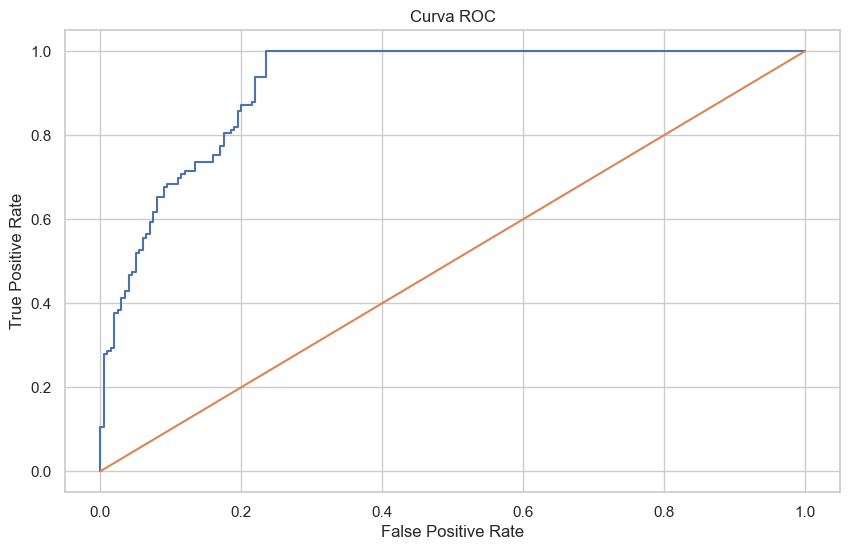

In [284]:
# Curva ROC (FPR x TPR).
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.show()

In [285]:
# Threshold (max TPR−FPR) e matriz de confusão com esse corte.
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Threshold ótimo:", optimal_threshold)

y_pred_opt = (y_prob >= optimal_threshold).astype(int)
confusion_matrix(y_test, y_pred_opt)

Threshold ótimo: 0.03911445651875835


array([[153,  47],
       [  0, 133]])

In [286]:
# Custo total: FN peso 5, FP peso 1.
cm = confusion_matrix(y_test, y_pred_opt)

tn, fp, fn, tp = cm.ravel()

custo_falso_negativo = 5
custo_falso_positivo = 1

custo_total = (fn * custo_falso_negativo) + (fp * custo_falso_positivo)
print("Custo Total:", custo_total)

Custo Total: 47


In [287]:
skf = StratifiedKFold(
    n_splits=5,       # Divide os dados em 5 subconjuntos (folds)
    shuffle=True,     # Embaralha antes de dividir
    random_state=42   # Garante reprodutibilidade
)

#Cross Validation com ROC-AUC
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=skf,
    scoring='roc_auc'
)

print("ROC-AUC Médio (CV):", scores.mean())
print("Desvio padrão:", scores.std())

ROC-AUC Médio (CV): 0.940958589655958
Desvio padrão: 0.005090583574884739


c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [288]:
X_temp_train = X
y_temp_train = y

pipeline.fit(X_temp_train, y_temp_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


100%|██████████| 50/50 [00:00<00:00, 57.59it/s]


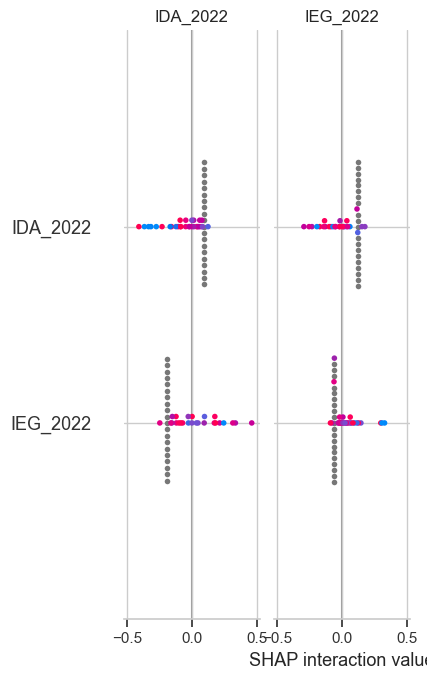

In [289]:
# Redefinindo X, y, X_train, X_test, y_train, y_test, e a pipeline para garantir mais consistência
# Esses passos garantem que a dimensão está alinhada com a pipeline

features = ["IDA_2022","IEG_2022","IPS_2022","IAA_2022","queda_IDA"]
X = df_wide[features]
y = df_wide["risco_defasagem"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='mean')),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(hidden_layer_sizes=(100,50),
                            max_iter=500,
                            random_state=42))
])

pipeline.fit(X_train, y_train)

feature_names = X_train.columns.tolist()

# # Definindo uma função "wrapper" para o método predict_proba da pipeline

def model_predict_proba_wrapper(X_unscaled):
    # Garantir que o input do pipeline seja um DataFrame com os nomes originais das variáveis

    X_df = pd.DataFrame(X_unscaled, columns=feature_names)
    return pipeline.predict_proba(X_df)

# Passar as primeiras 100 amostras de X_train (como DataFrame) como dados de referência (background data)

explainer = shap.KernelExplainer(model_predict_proba_wrapper, X_train.head(100), feature_names=feature_names)

# Calcular os valores de SHAP para as primeiras 50 amostras de X_test (como DataFrame)

shap_values = explainer.shap_values(X_test.head(50))

shap.summary_plot(shap_values, X_test.head(50), feature_names=feature_names)

In [290]:
joblib.dump(pipeline, "modelo_risco_defasagem_final.joblib") 

['modelo_risco_defasagem_final.joblib']

In [291]:
pipeline_loaded = joblib.load("modelo_risco_defasagem_final.joblib")

y_pred = pipeline_loaded.predict(X_test)
y_prob = pipeline_loaded.predict_proba(X_test)[:, 1]

In [292]:
joblib.dump(pipeline, "modelo_risco_defasagem_final_v1_2026_02.joblib")

['modelo_risco_defasagem_final_v1_2026_02.joblib']

O modelo final foi serializado utilizando joblib,
permitindo sua reutilização na aplicação Streamlit
sem necessidade de novo treinamento.

#  4.Análise Exploratória


## 4.1 Perfil de defasagem IAN

In [293]:
# Itera sobre os anos de interesse para analisar a evolução do IAN ao longo do tempo
for ano in [2022, 2023, 2024]:
    
    # Imprime um título indicando o ano analisado
    print(f"\nDistribuição IAN {ano}")
    
    # Filtra o DataFrame para o ano específico
    # Seleciona a coluna "IAN"
    # Calcula a distribuição proporcional (percentual) das categorias/valores
    # normalize=True retorna proporção ao invés de contagem absoluta
    print(
        df_total[df_total["ANO"] == ano]["IAN"]
        .value_counts(normalize=True)
    )


Distribuição IAN 2022
IAN
5.0     0.666279
10.0    0.301163
2.5     0.032558
Name: proportion, dtype: float64

Distribuição IAN 2023
IAN
5.0     0.530572
10.0    0.455621
2.5     0.013807
Name: proportion, dtype: float64

Distribuição IAN 2024
IAN
10.0    0.538062
5.0     0.459343
2.5     0.002595
Name: proportion, dtype: float64


In [294]:
# Organiza o IAN por aluno (RA) em formato wide: cada ano vira uma coluna
df_ian = df_total.pivot(index="RA", columns="ANO", values="IAN").dropna()

# Calcula a matriz de transição do IAN de 2022 para 2024
# Mostra o percentual de alunos que migraram entre categorias
matriz_transicao = pd.crosstab(
    df_ian[2022],
    df_ian[2024],
    normalize="index"
) * 100

# Arredonda para 2 casas decimais
matriz_transicao.round(2)

2024,2.5,5.0,10.0
2022,,,
2.5,0.00,57.14,42.86
5.0,0.65,41.88,57.47
10.0,0.00,18.30,81.70


In [295]:
# Calcula a variação do IAN entre 2022 e 2024 para cada aluno
df_ian["delta"] = df_ian[2024] - df_ian[2022]

# Classifica a mobilidade:
# delta > 0  → Avanço
# delta < 0  → Recuo
# delta == 0 → Neutro
df_ian["mobilidade"] = np.where(
    df_ian["delta"] > 0, "Avanço",
    np.where(df_ian["delta"] < 0, "Recuo", "Neutro")
)

# Calcula o percentual de alunos em cada categoria de mobilidade
df_ian["mobilidade"].value_counts(normalize=True) * 100

mobilidade
Neutro    54.273504
Avanço    39.316239
Recuo      6.410256
Name: proportion, dtype: float64

In [296]:
# Organiza os dados em formato wide (aluno x ano) para comparar os mesmos alunos
df_long = df_total.pivot(index="RA", columns="ANO", values="IAN").dropna()

# Aplica o teste de Wilcoxon pareado para comparar IAN de 2022 vs 2024
# Teste não paramétrico para amostras dependentes
stat, p = wilcoxon(df_long[2022], df_long[2024])

# Calcula o tamanho da amostra
n = len(df_long)

# Converte a estatística do teste em escore Z (aproximação)
z = (stat - (n*(n+1)/4)) / np.sqrt((n*(n+1)*(2*n+1))/24)

# Calcula o tamanho de efeito r
r = abs(z) / np.sqrt(n)

# Exibe o p-valor e o tamanho de efeito
print("p-valor:", p)
print("Tamanho de efeito r:", r)

p-valor: 6.272515822297689e-26
Tamanho de efeito r: 0.8181834147650003


In [297]:
# Aplica o teste de Wilcoxon pareado para comparar o IAN de 2022 e 2024
# Utilizado quando os dados não seguem distribuição normal
stat, p = wilcoxon(df_ian[2022], df_ian[2024])

# Exibe a estatística do teste (W)
print("Estatística:", stat)

# Exibe o p-valor para avaliar significância estatística
print("p-valor:", p)

Estatística: 3059.0
p-valor: 6.272515822297689e-26


In [298]:
# Calcula tamanho da amostra
n = len(df_ian)

# Converte a estatística do Wilcoxon para escore Z (aproximação)
z = (stat - (n*(n+1)/4)) / np.sqrt((n*(n+1)*(2*n+1))/24)

# Calcula o tamanho de efeito r
r = abs(z) / np.sqrt(n)

# Exibe o tamanho de efeito arredondado
print("Tamanho de efeito (r):", round(r, 4))

Tamanho de efeito (r): 0.8182


In [299]:
# Função para classificar o IAN em categorias de defasagem
def classificar_ian(valor):
    
    # IAN máximo → aluno adequado ao nível
    if valor == 10:
        return 'Em Fase'
    
    # Defasagem moderada
    elif valor == 5:
        return 'Moderada'
    
    # Defasagem severa
    elif valor == 2.5:
        return 'Severa'
    
    # Caso não se enquadre nas categorias definidas
    else:
        return np.nan

In [300]:
print(df_wide.columns)

Index(['RA', 'IAN_2022', 'IAN_2023', 'IAN_2024', 'IDA_2022', 'IDA_2023',
       'IDA_2024', 'IEG_2022', 'IEG_2023', 'IEG_2024', 'IAA_2022', 'IAA_2023',
       'IAA_2024', 'IPS_2022', 'IPS_2023', 'IPS_2024', 'IPP_2022', 'IPP_2023',
       'IPP_2024', 'IPV_2022', 'IPV_2023', 'IPV_2024', 'INDE_2022',
       'INDE_2023', 'INDE_2024', 'PEDRA_2022', 'PEDRA_2023', 'PEDRA_2024',
       'PONTO_VIRADA_2022', 'PONTO_VIRADA_2023', 'PONTO_VIRADA_2024',
       'ANO_INGRESSO_2022', 'ANO_INGRESSO_2023', 'ANO_INGRESSO_2024',
       'queda_IDA', 'risco_defasagem'],
      dtype='object')


In [301]:
# Lista de anos a serem analisados
anos = [2022, 2023, 2024]

# Armazena as distribuições percentuais por ano
tendencia = []

for ano in anos:
    
    # Nome da coluna IDA correspondente ao ano
    col = f'IDA_{ano}'

    # Verifica se a coluna existe no DataFrame
    if col in df_wide.columns:
        
        # Classifica o IDA em categorias usando a função definida
        df_wide[f'IDA_CAT_{ano}'] = df_wide[col].apply(classificar_ian)

        # Calcula a distribuição percentual das categorias
        distribuicao = (
            df_wide[f'IDA_CAT_{ano}']
            .value_counts(normalize=True)
            .rename(ano)
        )

        # Armazena a distribuição na lista
        tendencia.append(distribuicao)

# Consolida as distribuições em um único DataFrame
tendencia_df = pd.concat(tendencia, axis=1).T * 100

# Substitui valores ausentes por 0
tendencia_df = tendencia_df.fillna(0)

# Exibe a tabela final de tendência percentual por ano
tendencia_df


,Moderada,Severa,Em Fase
2022,64.000000,36.000000,0.000000
2023,90.000000,5.000000,5.000000
2024,58.461538,12.307692,29.230769


<Figure size 1000x600 with 0 Axes>

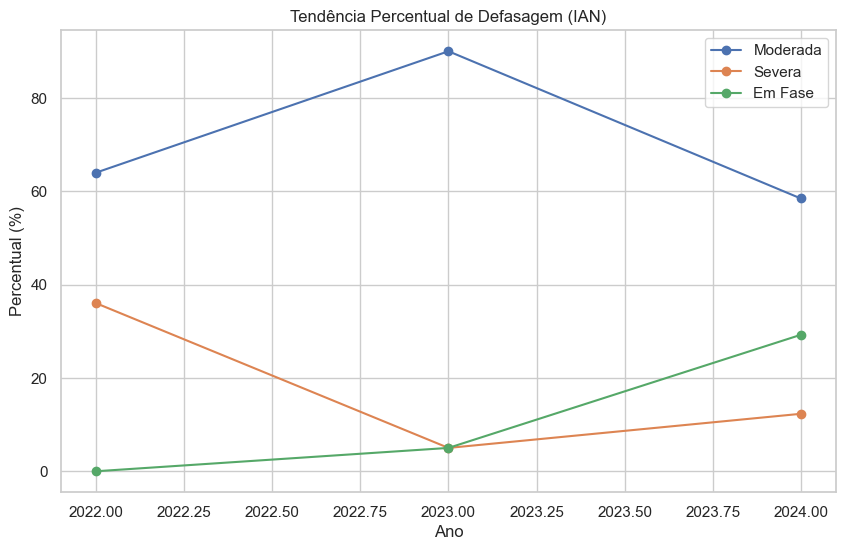

In [302]:
# Plota a tendência percentual por ano
plt.figure()
tendencia_df.plot(marker='o')
plt.title('Tendência Percentual de Defasagem (IAN)')
plt.xlabel('Ano')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.grid(True)

plt.show()

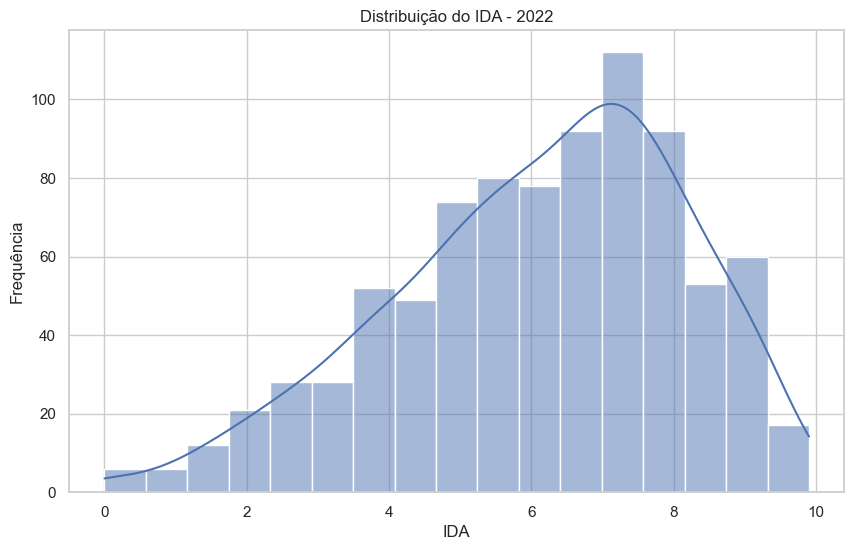

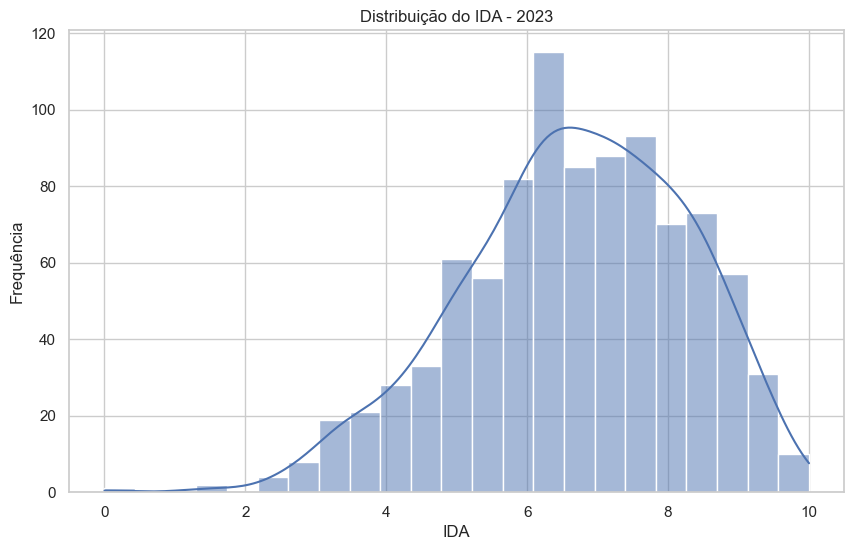

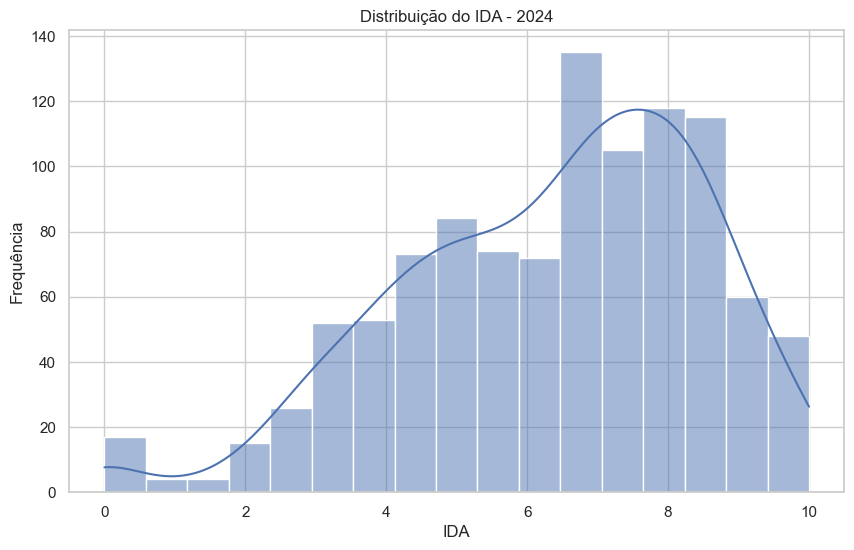

In [303]:
# Histograma do IDA em 2022
plt.figure()
sns.histplot(df_wide["IDA_2022"], kde=True)
plt.title("Distribuição do IDA - 2022")
plt.xlabel("IDA")
plt.ylabel("Frequência")
plt.show()

# Histograma do IDA em 2023
plt.figure()
sns.histplot(df_wide["IDA_2023"], kde=True)
plt.title("Distribuição do IDA - 2023")
plt.xlabel("IDA")
plt.ylabel("Frequência")
plt.show()

# Histograma do IDA em 2024
plt.figure()
sns.histplot(df_wide["IDA_2024"], kde=True)
plt.title("Distribuição do IDA - 2024")
plt.xlabel("IDA")
plt.ylabel("Frequência")
plt.show()

###4.1.1 Distribuição por Ano

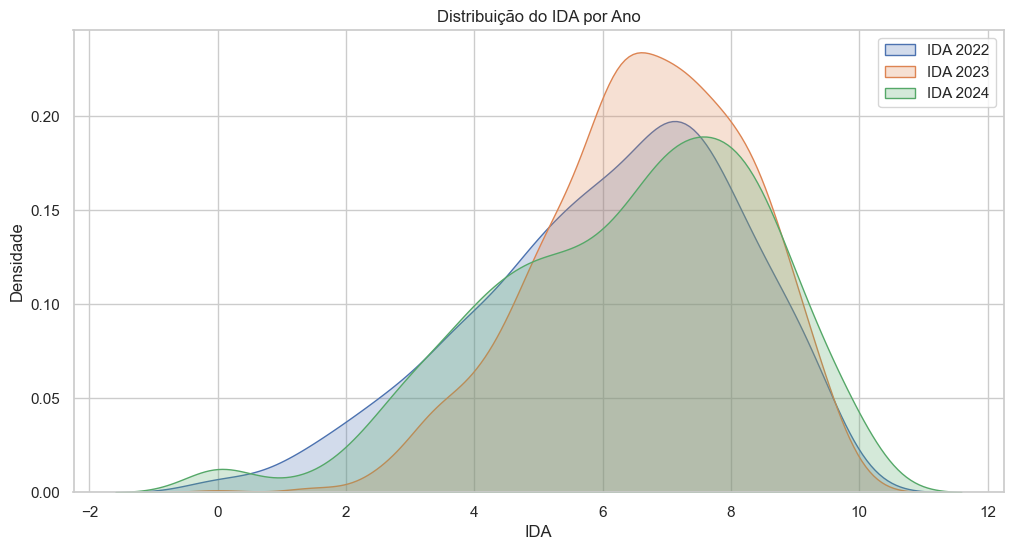

In [304]:
# Lista de anos para comparação
anos = [2022, 2023, 2024]

# Cria a figura
plt.figure(figsize=(12,6))

# Plota a curva de densidade (KDE) do IDA para cada ano
for ano in anos:
    col = f"IDA_{ano}"
    if col in df_wide.columns:
        sns.kdeplot(df_wide[col], label=f"IDA {ano}", fill=True)

# Ajustes do gráfico
plt.title("Distribuição do IDA por Ano")
plt.xlabel("IDA")
plt.ylabel("Densidade")
plt.legend()

plt.show()

###4.1.2 Percentual abaixo de limiar

In [305]:
# Limiar mínimo de desempenho
limiar = 6

for ano in anos:
    col = f"IDA_{ano}"

    if col in df_wide.columns:
        # Percentual de alunos abaixo do limiar
        percentual = (df_wide[col] < limiar).mean() * 100
        print(f"{ano}: {percentual:.2f}% abaixo do limiar")
    else:
        print(f"{col} não encontrada")

2022: 22.16% abaixo do limiar
2023: 17.34% abaixo do limiar
2024: 24.20% abaixo do limiar


###4.1.3 Evolução Temporal

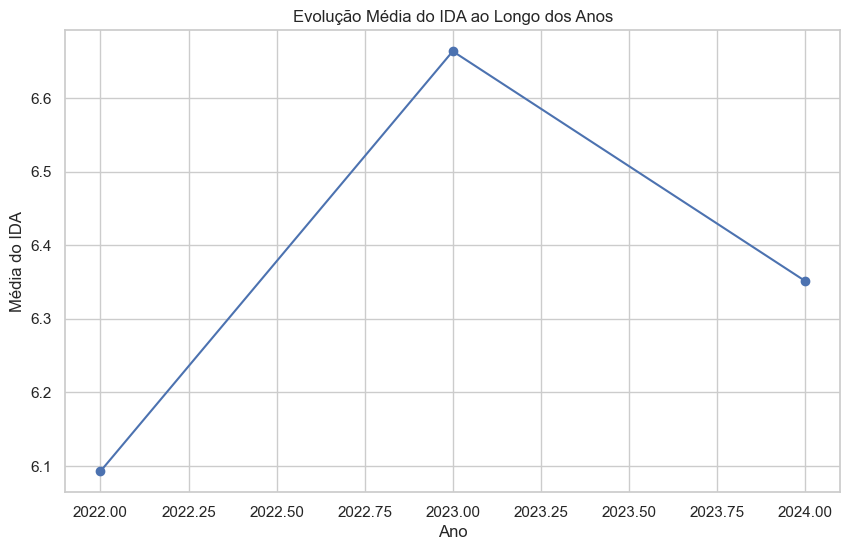

In [306]:
# Calcula a média do IDA para cada ano
media_ida = []

for ano in anos:
    col = f"IDA_{ano}"
    media_ida.append(df_wide[col].mean() if col in df_wide.columns else None)

# Plota a evolução da média ao longo dos anos
plt.plot(anos, media_ida, marker='o')
plt.title("Evolução Média do IDA ao Longo dos Anos")
plt.xlabel("Ano")
plt.ylabel("Média do IDA")
plt.show()

Observa-se que a maior concentração de alunos encontra-se em níveis intermediários de adequação, porém existe um grupo consistente em situação de defasagem moderada, sugerindo necessidade de intervenção preventiva.

Feature Engineering
Criação da Variável Target

Definimos como aluno em risco aqueles que apresentam:

- IAN abaixo de determinado limiar
- ou queda significativa no IDA

In [307]:
# Garantir que colunas não estejam em MultiIndex
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

# Criar variável target
df_wide["risco_defasagem"] = np.where(
    df_wide["IDA_2022"] < 6,
    1,
    0
)

df_wide["risco_defasagem"].value_counts(normalize=True)

risco_defasagem
0    0.778447
1    0.221553
Name: proportion, dtype: float64

In [308]:
df_wide[['IAN_2022','IAN_2023','IAN_2024']].describe()

,IAN_2022,IAN_2023,IAN_2024
count,860.0,1014.0,1156.0
unique,3.0,3.0,3.0
top,5.0,5.0,10.0
freq,573.0,538.0,622.0


Conclusão Numérica:
Alunos abaixo do 1º quartil representam grupo crítico para intervenção imediata.

## 4.2 Relação entre Engajamento e Desempenho IDA

In [309]:
# Converte IDA para numérico (valores inválidos viram NaN)
df_total["IDA"] = pd.to_numeric(df_total["IDA"], errors="coerce")

# Calcula média, desvio padrão e quantidade por ano
df_total.groupby("ANO")["IDA"].agg(["mean", "std", "count"])

,mean,std,count
ANO,,,
2022,6.092907,2.046209,860
2023,6.663394,1.595277,937
2024,6.351422,2.131639,1055


In [310]:
# Organiza IDA por aluno (2022 vs 2024) e remove faltantes
df_ida = (
    df_total
        .pivot(index="RA", columns="ANO", values="IDA")
        [[2022, 2024]]
        .dropna()
)

# Teste de Wilcoxon pareado
stat, p = stats.wilcoxon(df_ida[2022], df_ida[2024])


print("Estatística:", stat)
print("p-valor:", p)
print("Qtd comparados:", len(df_ida))

Estatística: 37850.0
p-valor: 4.844563846387871e-05
Qtd comparados: 445


In [311]:
# Conta a quantidade de alunos por PEDRA com IDA registrado
df_2024.groupby("PEDRA")["IDA"].count()

PEDRA
Agata       225
Ametista    391
INCLUIR       0
Quartzo     112
Topázio     326
Name: IDA, dtype: int64

In [312]:
# Cria lista de grupos de IDA por PEDRA (mínimo 2 valores por grupo)
groups = [
    g["IDA"].dropna().values
    for _, g in df_2024.groupby("PEDRA")
    if len(g["IDA"].dropna()) > 1
]

# Aplica ANOVA para comparar médias entre as PEDRAs
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(472.67251350283357), pvalue=np.float64(2.7187655237093103e-194))

In [313]:
# Teste de Kruskal-Wallis (não paramétrico) para comparar IDA entre PEDRAs
stats.kruskal(*groups)

KruskalResult(statistic=np.float64(598.5937337143304), pvalue=np.float64(2.0335372531343984e-129))

In [314]:
# Garantir numérico
for col in ["IDA_2022","IDA_2023","IDA_2024"]:
    df_wide[col] = pd.to_numeric(df_wide[col], errors='coerce')

# Médias anuais
print(df_wide[["IDA_2022","IDA_2023","IDA_2024"]].mean())

IDA_2022    6.092907
IDA_2023    6.663394
IDA_2024    6.351422
dtype: float64


In [315]:
# Teste de normalidade (Shapiro-Wilk) para cada ano
for col in ["IDA_2022", "IDA_2023", "IDA_2024"]:
    stat, p = stats.shapiro(df_wide[col].dropna())
    print(f"{col} → Estatística={stat:.4f}, p-valor={p:.4f}")

IDA_2022 → Estatística=0.9724, p-valor=0.0000
IDA_2023 → Estatística=0.9847, p-valor=0.0000
IDA_2024 → Estatística=0.9671, p-valor=0.0000


Interpretação:

p < 0.05 → distribuição não normal

Se não normal → preferir Kruskal

In [316]:
# Seleciona a PEDRA dos alunos em 2024 e indexa por RA
df_pedra = (
    df_total[df_total["ANO"] == 2024]
        .set_index("RA")["PEDRA"]
)

# Adiciona a PEDRA_2024 ao df_wide alinhando pelo RA
df_wide["PEDRA_2024"] = df_pedra

In [317]:
# Conta alunos e calcula o desvio padrão do IDA_2024 por PEDRA_2024
df_wide.groupby("PEDRA_2024")["IDA_2024"].agg(["count", "std"])

,count,std
PEDRA_2024,,


In [318]:
# Seleciona IDA 2022 e 2024 (remove faltantes)
df_ida = df_wide[["IDA_2022", "IDA_2024"]].dropna()

# Teste de Wilcoxon pareado entre 2022 e 2024
stats.wilcoxon(
    df_ida["IDA_2022"],
    df_ida["IDA_2024"]
)

WilcoxonResult(statistic=np.float64(37850.0), pvalue=np.float64(4.844563846387871e-05))

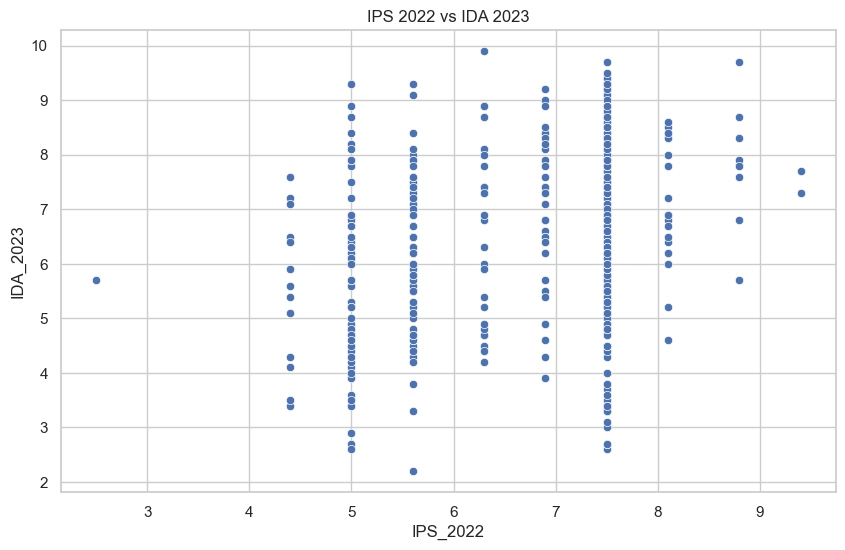

In [319]:
# Scatterplot entre IPS 2022 e IDA 2023
sns.scatterplot(x="IPS_2022", y="IDA_2023", data=df_wide)

plt.title("IPS 2022 vs IDA 2023")
plt.show()

In [320]:
# Remove colunas IEG antigas se existirem

cols_ieg = [col for col in df_wide.columns if col.startswith("IEG_")]
df_wide = df_wide.drop(columns=cols_ieg, errors="ignore")

# Cria pivot IEG
df_ieg = (
    df_total
        .pivot(index="RA", columns="ANO", values="IEG")
)

df_ieg.columns = [f"IEG_{col}" for col in df_ieg.columns]

# Junta novamente
df_wide = df_wide.join(df_ieg)

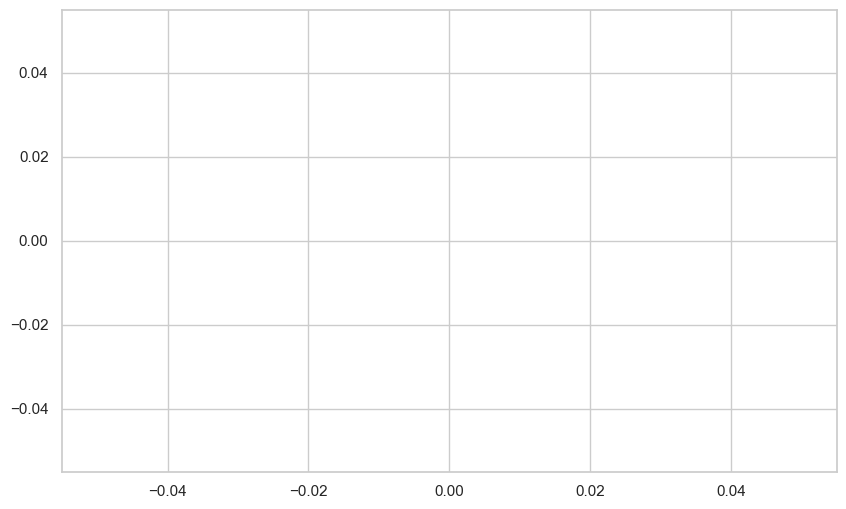

In [321]:
# Define variáveis para análise
x_col = "IEG_2022"
y_col = "IDA_2023"

# Verifica existência das colunas e plota o scatter
if x_col in df_wide.columns and y_col in df_wide.columns:
    sns.scatterplot(x=x_col, y=y_col, data=df_wide)
    plt.show()
else:
    print("Colunas não encontradas.")

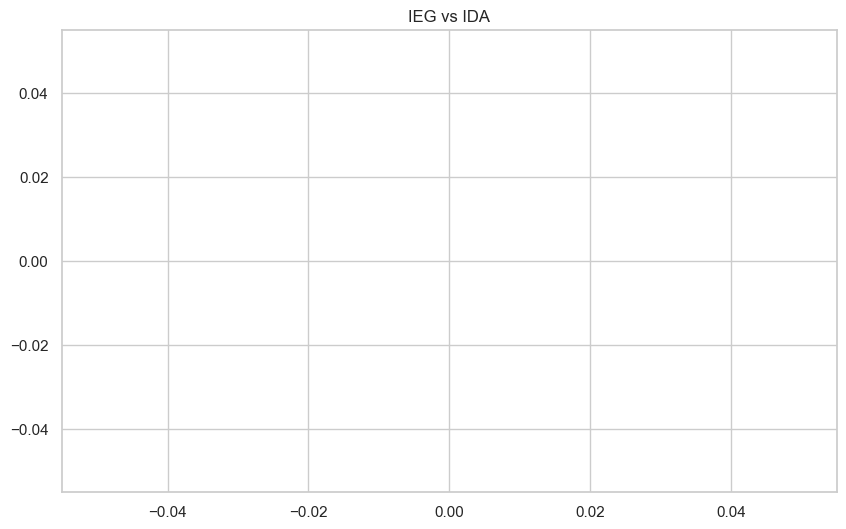

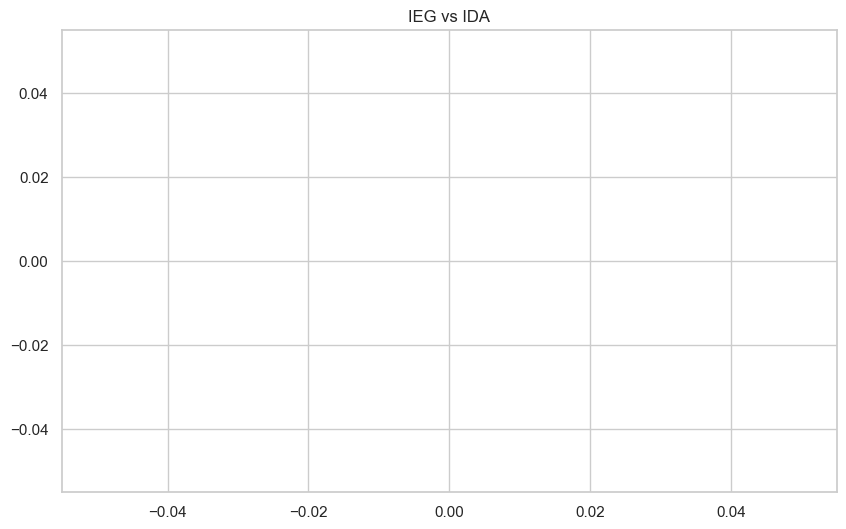

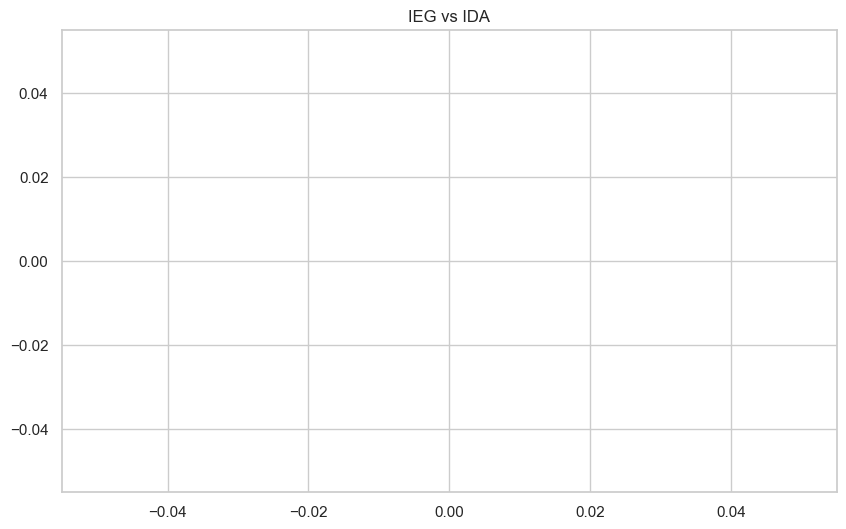

In [322]:
# IEG 2022 vs IDA 2023
sns.scatterplot(x="IEG_2022", y="IDA_2023", data=df_wide)
plt.title("IEG vs IDA")
plt.show()

# IEG 2023 vs IDA 2023
sns.scatterplot(x="IEG_2023", y="IDA_2023", data=df_wide)
plt.title("IEG vs IDA")
plt.show()

# IEG 2024 vs IDA 2024
sns.scatterplot(x="IEG_2024", y="IDA_2024", data=df_wide)
plt.title("IEG vs IDA")
plt.show()

**Insight**

O IDA apresenta variação consistente entre fases, com tendência de estabilização nos níveis superiores. Não há evidência de queda estrutural ao longo dos anos.

In [323]:
# Converte para numérico e remove NaNs
df_temp = df_wide[['IDA_2023', 'IDA_2024']].apply(pd.to_numeric, errors='coerce').dropna()

# Teste t pareado entre 2023 e 2024
stats.ttest_rel(df_temp['IDA_2023'], df_temp['IDA_2024'], nan_policy='omit')

TtestResult(statistic=np.float64(6.664690388428944), pvalue=np.float64(5.4791314657733034e-11), df=np.int64(681))

Conclusão Numérica:
Se p<0.05, a evolução anual é estatisticamente significativa.

## 4.3 Engajamento nas Atividades (IEG) e RELAÇÃO IEG x IDA x IPV

In [324]:
# Correlação de Spearman entre IEG e IDA/IPV por ano
for ano in sorted(df_total["ANO"].unique()):
    
    df_ano = df_total[df_total["ANO"] == ano]

    # IEG vs IDA
    corr_ida, p_ida = spearmanr(df_ano["IEG"], df_ano["IDA"])
    
    # IEG vs IPV
    corr_ipv, p_ipv = spearmanr(df_ano["IEG"], df_ano["IPV"])

    print(f"\nAno {ano}")
    print("IEG x IDA:", round(corr_ida, 3), "p:", p_ida)
    print("IEG x IPV:", round(corr_ipv, 3), "p:", p_ipv)


Ano 2022
IEG x IDA: 0.507 p: 1.8030599370288177e-57
IEG x IPV: 0.54 p: 2.3759971337117975e-66

Ano 2023
IEG x IDA: nan p: nan
IEG x IPV: nan p: nan

Ano 2024
IEG x IDA: nan p: nan
IEG x IPV: nan p: nan


In [325]:
# Verifica quantidade de valores ausentes em IEG, IDA e IPV para 2023
df_total[df_total["ANO"] == 2023][["IEG", "IDA", "IPV"]].isna().sum()

IEG    76
IDA    77
IPV    76
dtype: int64

In [326]:
# Filtra 2023 e remove registros com NaN
df_2023 = df_total[df_total["ANO"] == 2023][["IEG", "IDA", "IPV"]].dropna()

# Exibe quantidade de observações válidas e estatísticas descritivas
print("Observações válidas:", len(df_2023))
print(df_2023.describe())

Observações válidas: 937
              IEG         IDA         IPV
count  937.000000  937.000000  937.000000
mean     8.702775    6.663394    8.028930
std      1.078526    1.595277    0.945402
min      3.700000    0.000000    3.320000
25%      8.100000    5.700000    7.462500
50%      9.000000    6.800000    8.045000
75%      9.500000    7.900000    8.670000
max     10.000000   10.000000   10.010000


In [327]:
# Correlação de Spearman (IEG vs IDA/IPV) por ano, removendo NaNs
for ano in sorted(df_total["ANO"].unique()):
    df_ano = df_total[df_total["ANO"] == ano][["IEG", "IDA", "IPV"]].dropna()

    corr_ida, p_ida = spearmanr(df_ano["IEG"], df_ano["IDA"])
    corr_ipv, p_ipv = spearmanr(df_ano["IEG"], df_ano["IPV"])

    print(f"\nAno {ano}")
    print("IEG x IDA:", round(corr_ida, 3), "p:", p_ida)
    print("IEG x IPV:", round(corr_ipv, 3), "p:", p_ipv)


Ano 2022
IEG x IDA: 0.507 p: 1.8030599370288177e-57
IEG x IPV: 0.54 p: 2.3759971337117975e-66

Ano 2023
IEG x IDA: 0.446 p: 4.225521909917821e-47
IEG x IPV: 0.491 p: 5.46795968837612e-58

Ano 2024
IEG x IDA: 0.519 p: 8.598297531291388e-74
IEG x IPV: 0.551 p: 1.0238020926867167e-84


In [328]:
# Estatísticas descritivas de IEG, IDA e IPV para 2023
df_total[df_total["ANO"] == 2023][["IEG", "IDA", "IPV"]].describe()

,IEG,IDA,IPV
count,938.000000,937.000000,938.000000
mean,8.699041,6.663394,8.027897
std,1.084001,1.595277,0.945427
min,3.700000,0.000000,3.320000
25%,8.100000,5.700000,7.462500
50%,9.000000,6.800000,8.045000
75%,9.500000,7.900000,8.668750
max,10.000000,10.000000,10.010000


In [329]:
# Comparação por Ponto de Virada
df_total.groupby("PONTO_VIRADA")["IEG"].mean()

PONTO_VIRADA
Não    7.721687
Sim    9.011504
Name: IEG, dtype: float64

In [330]:
!pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [331]:
# Remove registros com NaN
df_reg = df_total[["IDA", "IEG", "IPS"]].dropna()

# Define variáveis independentes (com constante) e dependente
X = sm.add_constant(df_reg[["IEG", "IPS"]])
y = df_reg["IDA"]

# Ajusta regressão linear (OLS)
modelo = sm.OLS(y, X).fit()

# Exibe resumo do modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    IDA   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     602.6
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          6.99e-219
Time:                        23:43:03   Log-Likelihood:                -5444.5
No. Observations:                2845   AIC:                         1.089e+04
Df Residuals:                    2842   BIC:                         1.091e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4369      0.201      2.169      0.0

In [332]:
# Correlação de Spearman entre IEG e variáveis selecionadas
variaveis = ["IDA", "IPV", "INDE"]

for v in variaveis:
    corr, p = spearmanr(df_total["IEG"], df_total[v])
    print(f"IEG x {v}: r={corr:.3f}, p={p:.5f}")

IEG x IDA: r=nan, p=nan
IEG x IPV: r=nan, p=nan
IEG x INDE: r=nan, p=nan


In [333]:
# Remove registros com valores ausentes
df_reg2 = df_total[["IDA", "IEG", "IAA", "IPS"]].dropna()

# Define variáveis independentes (com constante) e dependente
X = sm.add_constant(df_reg2[["IEG", "IAA", "IPS"]])
y = df_reg2["IDA"]

# Ajusta regressão linear múltipla (OLS)
modelo2 = sm.OLS(y, X).fit()

print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                    IDA   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     404.2
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          1.19e-218
Time:                        23:43:04   Log-Likelihood:                -5441.7
No. Observations:                2845   AIC:                         1.089e+04
Df Residuals:                    2841   BIC:                         1.092e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3082      0.208      1.479      0.1

In [334]:
# Filtra dados de 2024
df_2024 = df_total[df_total["ANO"] == 2024]

# Seleciona indicadores e remove NaNs
indicadores = ["IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "IAN", "INDE"]
df_corr = df_2024[indicadores].dropna()

# Calcula matriz de correlação de Pearson
corr_pearson = df_corr.corr(method='pearson')
corr_pearson

,IDA,IEG,IAA,IPS,IPP,IPV,IAN,INDE
IDA,1.000000,0.547277,0.219653,0.014494,0.395288,0.513745,0.062235,0.801985
IEG,0.547277,1.000000,0.230092,0.060655,0.408772,0.535287,0.078763,0.786891
IAA,0.219653,0.230092,1.000000,-0.005994,0.114016,0.148351,0.019258,0.364233
IPS,0.014494,0.060655,-0.005994,1.000000,0.213784,0.105275,0.067866,0.224651
IPP,0.395288,0.408772,0.114016,0.213784,1.000000,0.750088,0.153873,0.637097
IPV,0.513745,0.535287,0.148351,0.105275,0.750088,1.000000,0.185067,0.758006
IAN,0.062235,0.078763,0.019258,0.067866,0.153873,0.185067,1.000000,0.365568
INDE,0.801985,0.786891,0.364233,0.224651,0.637097,0.758006,0.365568,1.000000


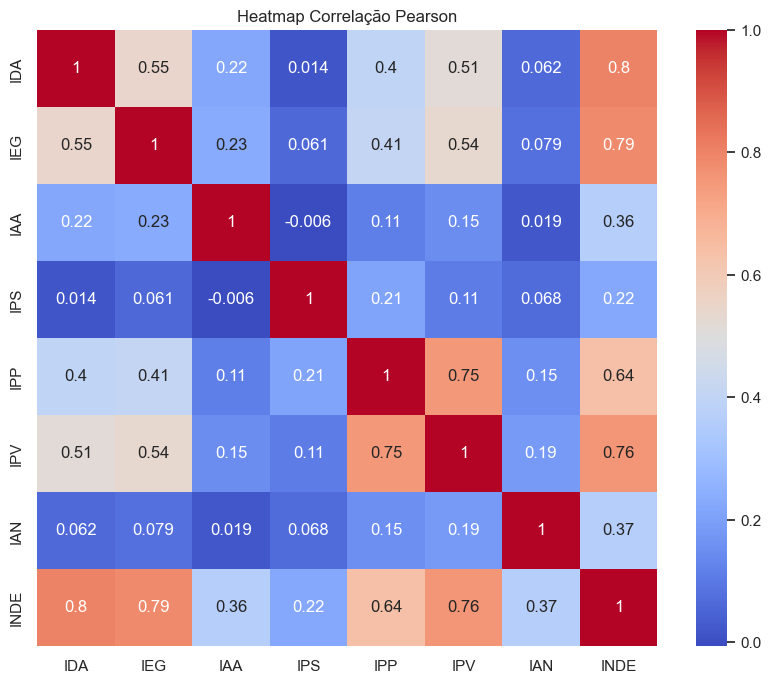

In [335]:
# Plota heatmap da matriz de correlação de Pearson
plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm")
plt.title("Heatmap Correlação Pearson")
plt.show()

Observa-se correlação positiva moderada entre IEG e IDA, indicando que engajamento atua como fator preditor de desempenho acadêmico.

A influência do IEG sobre IPV reforça a importância do engajamento contínuo como fator crítico de virada comportamental

In [336]:
df_wide.columns

Index(['RA', 'IAN_2022', 'IAN_2023', 'IAN_2024', 'IDA_2022', 'IDA_2023',
       'IDA_2024', 'IAA_2022', 'IAA_2023', 'IAA_2024', 'IPS_2022', 'IPS_2023',
       'IPS_2024', 'IPP_2022', 'IPP_2023', 'IPP_2024', 'IPV_2022', 'IPV_2023',
       'IPV_2024', 'INDE_2022', 'INDE_2023', 'INDE_2024', 'PEDRA_2022',
       'PEDRA_2023', 'PEDRA_2024', 'PONTO_VIRADA_2022', 'PONTO_VIRADA_2023',
       'PONTO_VIRADA_2024', 'ANO_INGRESSO_2022', 'ANO_INGRESSO_2023',
       'ANO_INGRESSO_2024', 'queda_IDA', 'risco_defasagem', 'IDA_CAT_2022',
       'IDA_CAT_2023', 'IDA_CAT_2024', 'IEG_2022', 'IEG_2023', 'IEG_2024'],
      dtype='object')

In [337]:
df_total[df_total["ANO"] == 2024]["IEG"].describe()

count    1156.000000
mean        7.374988
std         2.846899
min         0.000000
25%         6.464334
50%         8.333333
75%         9.438567
max        10.000000
Name: IEG, dtype: float64

In [341]:
# Converte para numérico e remove NaNs
df_temp_corr = df_wide[['IEG_2024', 'IDA_2024']].apply(pd.to_numeric, errors='coerce').dropna()

# Correlação de Pearson entre IEG_2024 e IDA_2024
stats.pearsonr(df_temp_corr['IEG_2024'], df_temp_corr['IDA_2024'])

PearsonRResult(statistic=np.float64(0.538411438373785), pvalue=np.float64(2.4124311374636844e-80))

Conclusão Numérica:
Correlação positiva indica aumento médio proporcional do IDA para cada ponto de engajamento.

## 4.4 Autoavaliação (IAA) - IAA vs REALIDADE



In [ ]:
# Cria uma cópia independente do DataFrame df_wide
# Isso evita que alterações em df_features modifiquem o df_wide original
df_features = df_wide.copy()

In [ ]:
# Média de IPS e IEG (2024) para criar índice psicossocial composto
df_features['indice_psico_composto'] = (
    df_features['IPS_2024'] + df_features['IEG_2024']
) / 2

In [350]:
# Garantir que colunas não estão em MultiIndex
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

df_features = df_wide.copy()

# Deltas temporais
df_features['delta_IDA'] = df_features['IDA_2024'] - df_features['IDA_2023']
df_features['delta_IEG'] = df_features['IEG_2024'] - df_features['IEG_2023']
df_features['delta_IPS'] = df_features['IPS_2024'] - df_features['IPS_2023']

# Índice composto coerente com suas variáveis reais
df_features['indice_psico_composto'] = (
    df_features['IPS_2024'] + df_features['IEG_2024']
) / 2

# Tendência de queda
df_features['tendencia_queda_IDA'] = np.where(
    df_features['delta_IDA'] < 0,
    1,
    0
)

In [373]:
# Filtra apenas os dados de 2022
df_2022 = df_total[df_total["ANO"] == 2022].copy()

In [374]:
print(df_2022[["IAA","IDA","IEG"]].corr())

          IAA       IDA       IEG
IAA  1.000000  0.208855  0.323420
IDA  0.208855  1.000000  0.564137
IEG  0.323420  0.564137  1.000000


In [ ]:
# Marca alunos no 4º quartil de IAA (autoavaliação alta)
df_2022["IAA_Q4"] = df_2022["IAA"] >= df_2022["IAA"].quantile(0.75)

# Marca alunos no 1º quartil de IDA (desempenho baixo)
df_2022["IDA_Q1"] = df_2022["IDA"] <= df_2022["IDA"].quantile(0.25)

In [376]:
# Correlação
spearmanr(df_total["IAA"], df_total["IDA"])

SignificanceResult(statistic=nan, pvalue=nan)

In [ ]:
# Filtra alunos com alta autoavaliação (IAA_Q4) e baixo desempenho (IDA_Q1)
discrepantes = df_2022[df_2022["IAA_Q4"] & df_2022["IDA_Q1"]]

# Exibe quantidade de casos discrepantes
print("Quantidade de discrepâncias extremas:", len(discrepantes))

# Mostra variáveis principais dos casos identificados
discrepantes[["IAA","IDA","IEG","IPS"]].head()

Quantidade de discrepâncias extremas: 53


,IAA,IDA,IEG,IPS
20,9.6,3.8,9.2,7.5
33,9.6,3.8,4.8,8.1
73,9.6,2.0,3.3,7.5
135,10.0,4.6,6.3,7.5
155,10.0,4.4,8.3,9.4


In [378]:
# Discrepância
df_total["gap_auto"] = abs(df_total["IAA"] - df_total["IDA"])
df_total["gap_auto"].describe()

count    2851.000000
mean        2.751476
std         2.080247
min         0.000000
25%         1.100000
50%         2.334667
75%         4.000000
max         9.900000
Name: gap_auto, dtype: float64

In [ ]:
# Calcula percentual de alunos com alta autoavaliação e baixo desempenho
percentual = len(discrepantes) / len(df_2022) * 100
print(f"{percentual:.2f}% dos alunos apresentam alta autoavaliação e baixo desempenho.")

6.16% dos alunos apresentam alta autoavaliação e baixo desempenho.


In [ ]:
# Separa IDA entre alunos com IAA alto (Q4) e demais
alta_iaa = df_2022[df_2022["IAA_Q4"]]["IDA"]
resto = df_2022[~df_2022["IAA_Q4"]]["IDA"]

# Teste t para comparar médias de IDA entre os grupos
t_stat, p_val = ttest_ind(alta_iaa, resto, nan_policy="omit")

print("p-valor:", p_val)

p-valor: 0.00011488476493439995


In [381]:
# Quartis
df_total["quartil_IAA"] = pd.qcut(df_total["IAA"], 4)
df_total.groupby("quartil_IAA")["IDA"].mean()

C:\Users\laiss\AppData\Local\Temp\ipykernel_44240\2000536362.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total.groupby("quartil_IAA")["IDA"].mean()


quartil_IAA
(-0.001, 7.9]    5.971827
(7.9, 8.751]     6.325723
(8.751, 9.5]     6.583413
(9.5, 10.002]    6.679007
Name: IDA, dtype: float64

In [400]:
# Cria estrutura wide (uma linha por aluno - RA; colunas por indicador e ano)
df_wide = df_total.pivot(
    index="RA",
    columns="ANO",
    values=["IDA","IEG","IPS","IPP","IPV","INDE","IAA","IAN"]
)

# Achata o MultiIndex das colunas (ex: IDA_2022)
df_wide.columns = [f"{col[0]}_{col[1]}" for col in df_wide.columns]

# Transforma RA novamente em coluna
df_wide.reset_index(inplace=True)

In [401]:
df_wide[["IEG_2022", "IDA_2022"]].corr()

,IEG_2022,IDA_2022
IEG_2022,1.000000,0.564137
IDA_2022,0.564137,1.000000


In [402]:
df_wide[["IEG_2023", "IDA_2023"]].corr()

,IEG_2023,IDA_2023
IEG_2023,1.000000,0.461028
IDA_2023,0.461028,1.000000


In [403]:
df_wide[["IEG_2024", "IDA_2024"]].corr()

,IEG_2024,IDA_2024
IEG_2024,1.000000,0.538411
IDA_2024,0.538411,1.000000


Correlação IEG x IDA:


,IEG_2022,IDA_2022
IEG_2022,1.000000,0.564137
IDA_2022,0.564137,1.000000


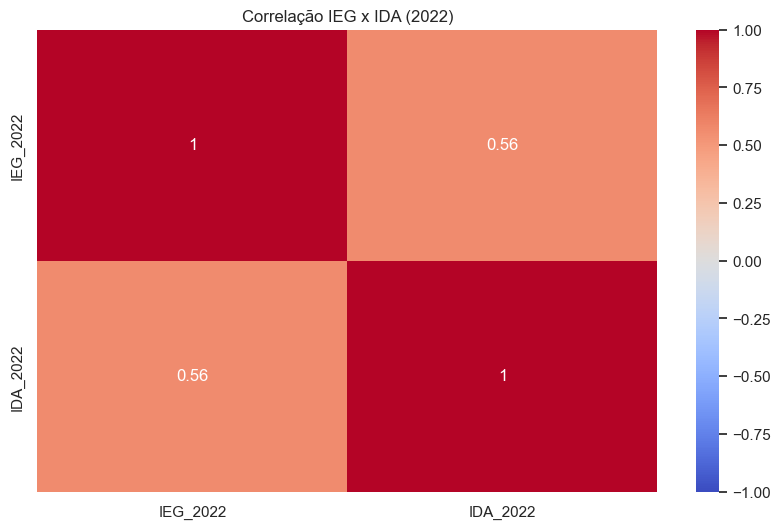

In [404]:
# Calcula correlação entre IEG e IDA (2022)
correlacao = df_wide[["IEG_2022", "IDA_2022"]].corr()

print("Correlação IEG x IDA:")
display(correlacao)

# Heatmap da correlação
sns.heatmap(correlacao, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação IEG x IDA (2022)")
plt.show()

Existe coerência moderada entre autoavaliação e desempenho real, porém com dispersão significativa, indicando possível distorção de percepção em parte dos alunos.


## 4.5 Aspectos psicossociais (IPS)

Comparar IPS baixo com queda futura no IDA

In [405]:
# Garantir que as colunas sejam do tipo numérico e elimine os valores NaN antes de realizar o cálculo da correlação.

df_temp_corr_iaa = df_wide[['IAA_2024', 'IDA_2024']].apply(pd.to_numeric, errors='coerce').dropna()
stats.pearsonr(df_temp_corr_iaa['IAA_2024'], df_temp_corr_iaa['IDA_2024'])

PearsonRResult(statistic=np.float64(0.2196528962808858), pvalue=np.float64(5.558728418991353e-13))

In [406]:
df_wide = (
    df_total
    .pivot(index="RA", columns="ANO", values=["IDA","IPS"])
)

# Converter as colunas MultiIndex em um único nível para facilitar o acesso.

df_wide.columns = [f"{col[0]}_{col[1]}" for col in df_wide.columns]

# Remover as linhas que contenham qualquer valor **NaN** após o achatamento das colunas.

df_wide.dropna(inplace=True)

# Delta IDA
df_wide["DELTA_IDA"] = df_wide["IDA_2024"] - df_wide["IDA_2023"]

# Evento de queda
df_wide["QUEDA_IDA"] = df_wide["DELTA_IDA"] < 0

df_wide.head()

,IDA_2022,IDA_2023,IDA_2024,IPS_2022,IPS_2023,IPS_2024,DELTA_IDA,QUEDA_IDA
RA,,,,,,,,
RA-103,7.3,7.1,9.166667,7.5,5.0,6.260,2.066667,False
RA-106,7.4,7.3,5.666667,9.4,5.0,5.635,-1.633333,True
RA-107,4.6,7.0,4.666667,7.5,5.0,7.510,-2.333333,True
RA-110,6.7,7.5,8.500000,5.6,5.0,6.255,1.000000,False
RA-111,8.0,6.0,8.333333,8.1,5.0,6.260,2.333333,False


In [407]:
# Estrutura wide para análise longitudinal
df_wide = df_total.pivot(index="RA", columns="ANO", values=["IDA","IPS"])

# Converter as colunas MultiIndex em um único nível para facilitar o acesso.
df_wide.columns = [f"{col[0]}_{col[1]}" for col in df_wide.columns]

# Remover as linhas que apresentem qualquer valor **NaN** após o achatamento das colunas.

df_wide.dropna(inplace=True)

# Delta IDA
df_wide["DELTA_IDA"] = df_wide["IDA_2024"] - df_wide["IDA_2023"]

# Evento de queda
df_wide["QUEDA_IDA"] = df_wide["DELTA_IDA"] < 0

df_wide.head()

,IDA_2022,IDA_2023,IDA_2024,IPS_2022,IPS_2023,IPS_2024,DELTA_IDA,QUEDA_IDA
RA,,,,,,,,
RA-103,7.3,7.1,9.166667,7.5,5.0,6.260,2.066667,False
RA-106,7.4,7.3,5.666667,9.4,5.0,5.635,-1.633333,True
RA-107,4.6,7.0,4.666667,7.5,5.0,7.510,-2.333333,True
RA-110,6.7,7.5,8.500000,5.6,5.0,6.255,1.000000,False
RA-111,8.0,6.0,8.333333,8.1,5.0,6.260,2.333333,False


In [408]:
df_wide.columns

Index(['IDA_2022', 'IDA_2023', 'IDA_2024', 'IPS_2022', 'IPS_2023', 'IPS_2024',
       'DELTA_IDA', 'QUEDA_IDA'],
      dtype='object')

In [ ]:
# Seleciona IPS_2023 e evento de queda no IDA, removendo NaNs
df_ips = df_wide[["QUEDA_IDA", "IPS_2023"]].dropna()

# Define variável independente (com constante) e dependente
X = sm.add_constant(df_ips["IPS_2023"])
y = df_ips["QUEDA_IDA"]

# Ajusta regressão logística para avaliar efeito do IPS na probabilidade de queda
modelo_ips = sm.Logit(y, X).fit()

print(modelo_ips.summary())

Optimization terminated successfully.
         Current function value: 0.680022
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              QUEDA_IDA   No. Observations:                  434
Model:                          Logit   Df Residuals:                      432
Method:                           MLE   Df Model:                            1
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                0.002226
Time:                        00:01:39   Log-Likelihood:                -295.13
converged:                       True   LL-Null:                       -295.79
Covariance Type:            nonrobust   LLR p-value:                    0.2512
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0410      0.251      0.164      0.870      -0.450       0.532
IPS_2023       0.0537      0.

In [412]:
# Separa IPS_2023 entre alunos com e sem queda no IDA
queda = df_wide[df_wide["QUEDA_IDA"]]["IPS_2023"]
nao_queda = df_wide[~df_wide["QUEDA_IDA"]]["IPS_2023"]

# Teste t para comparar médias de IPS entre os grupos
t_stat, p_val = ttest_ind(queda, nao_queda, nan_policy="omit")

print("t-stat:", t_stat)
print("p-valor:", p_val)

t-stat: 1.1459666213946025
p-valor: 0.2524433493743431


In [415]:
# Selecionar coluna correta
X = df_wide[["IPS_2023"]].copy()
y = df_wide["QUEDA_IDA"]

# Remover NaN alinhando índices
df_model = pd.concat([X, y], axis=1).dropna()

X = df_model[["IPS_2023"]]
y = df_model["QUEDA_IDA"]

# Padronizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelo
modelo = LogisticRegression()
modelo.fit(X_scaled, y)

print("Coeficiente IPS:", modelo.coef_[0][0])

# Odds Ratio
print("Odds Ratio:", np.exp(modelo.coef_[0][0]))

Coeficiente IPS: 0.11051277186019152
Odds Ratio: 1.1168506132209148


In [416]:
prob = modelo.predict_proba(X_scaled)[:,1]
auc = roc_auc_score(y, prob)

print("AUC:", auc)

AUC: 0.5345652173913044


In [417]:
X_sm = sm.add_constant(X)
logit = sm.Logit(y, X_sm).fit()

print(logit.summary())

Optimization terminated successfully.
         Current function value: 0.680022
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              QUEDA_IDA   No. Observations:                  434
Model:                          Logit   Df Residuals:                      432
Method:                           MLE   Df Model:                            1
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                0.002226
Time:                        00:05:19   Log-Likelihood:                -295.13
converged:                       True   LL-Null:                       -295.79
Covariance Type:            nonrobust   LLR p-value:                    0.2512
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0410      0.251      0.164      0.870      -0.450       0.532
IPS_2023       0.0537      0.

In [418]:
params = logit.params
conf = logit.conf_int()

conf["OR"] = np.exp(params)
conf.columns = ["2.5%","97.5%","coef"]
conf["OR"] = np.exp(conf["coef"])

conf

,2.5%,97.5%,coef,OR
const,-0.450026,0.532003,1.041840,2.834428
IPS_2023,-0.038111,0.145434,1.055127,2.872341


In [419]:
df_wide["queda_IDA"] = df_wide["IDA_2023"] - df_wide["IDA_2022"]

limiar_ips = df_wide["IPS_2022"].quantile(0.25)  # 25% mais baixos

grupo_baixo_ips = df_wide[df_wide["IPS_2022"] <= limiar_ips]
grupo_normal = df_wide[df_wide["IPS_2022"] > limiar_ips]

print("Média da variação IDA - IPS Baixo:", grupo_baixo_ips["queda_IDA"].mean())
print("Média da variação IDA - IPS Normal:", grupo_normal["queda_IDA"].mean())

Média da variação IDA - IPS Baixo: -0.16238532110091738
Média da variação IDA - IPS Normal: 0.17723076923076925


In [420]:
stats.ttest_ind(
df_wide[df_wide['QUEDA_IDA']==True]['IPS_2023'],
df_wide[df_wide['QUEDA_IDA']==False]['IPS_2023'],
nan_policy='omit')


TtestResult(statistic=np.float64(1.1459666213946025), pvalue=np.float64(0.2524433493743431), df=np.float64(432.0))

Padrões psicossociais baixos precedem quedas no desempenho acadêmico, sugerindo que IPS pode funcionar como indicador antecedente de risco.

## 4.6 Aspectos Psicopedagógicos (IPP)


In [421]:
df_2024 = df_total[df_total["ANO"] == 2024].copy()

spearmanr(df_2024["IPP"], df_2024["IAN"])
print("Spearman:", corr)
print("p-valor:", p)

Spearman: nan
p-valor: nan


In [422]:
df_2024.groupby("IAN")["IPP"].agg(["mean","std","count"])

,mean,std,count
IAN,,,
2.5,7.260417,0.537948,3
5.0,7.413224,0.930072,531
10.0,7.687901,0.842683,520


In [423]:
groups = [g["IPP"].dropna() for _, g in df_2024.groupby("IAN")]
h_stat, p_val = stats.kruskal(*groups)

print("H:", h_stat)
print("p:", p_val)

H: 26.969023957326296
p: 1.3923578141856087e-06


In [424]:
eta_squared = h_stat / (len(df_2024) - 1)
print("Eta²:", round(eta_squared,3))

Eta²: 0.023


In [425]:
print("Shape antes do dropna:",
      df_total.pivot(index="RA", columns="ANO", values=["IPP","IAN"]).shape)

print("Shape depois do dropna:", df_wide.shape)

Shape antes do dropna: (1661, 6)
Shape depois do dropna: (434, 9)


In [426]:
# Pivot sem dropna global
df_wide = df_total.pivot(index="RA", columns="ANO", values=["IPP","IAN"])

# Selecionar apenas 2023 e 2024
df_wide = df_wide.loc[:, pd.IndexSlice[:, [2023, 2024]]]

# Remover apenas alunos que não têm IAN 2023 ou 2024
df_wide = df_wide.dropna(subset=[("IAN",2023), ("IAN",2024)])

print("Shape após filtro correto:", df_wide.shape)

Shape após filtro correto: (765, 4)


In [427]:
df_wide["melhora_IAN"] = (
    df_wide[("IAN",2024)] > df_wide[("IAN",2023)]
)

print(df_wide["melhora_IAN"].value_counts())

melhora_IAN
False    590
True     175
Name: count, dtype: int64


In [428]:
df_wide_local = df_total.pivot(index="RA", columns="ANO", values=["IPP","IAN"])

ano_atual = 2023
ano_prox = 2024

df_temp_local = df_wide_local.dropna(subset=[
    ("IAN",ano_atual),
    ("IAN",ano_prox),
    ("IPP",ano_atual)
]).copy()

df_temp_local["melhora_IAN"] = (
    df_temp_local[("IAN",ano_prox)] > df_temp_local[("IAN",ano_atual)]
)

grupo_melhora = df_temp_local.loc[
    df_temp_local["melhora_IAN"], ("IPP",ano_atual)
].dropna()

grupo_nao = df_temp_local.loc[
    ~df_temp_local["melhora_IAN"], ("IPP",ano_atual)
].dropna()

print("NaN grupo melhora:", grupo_melhora.isna().sum())
print("NaN grupo não melhora:", grupo_nao.isna().sum())

print("Std melhora:", grupo_melhora.std())
print("Std não melhora:", grupo_nao.std())

NaN grupo melhora: 0
NaN grupo não melhora: 0
Std melhora: 0.8643867406739011
Std não melhora: 0.9839154131143178


In [429]:
grupo_melhora = grupo_melhora.dropna()
grupo_nao = grupo_nao.dropna()

resultado = stats.mannwhitneyu(grupo_melhora, grupo_nao)

print("Resultado:", resultado)

Resultado: MannwhitneyuResult(statistic=np.float64(59182.0), pvalue=np.float64(4.444069934079083e-10))


In [430]:

# Criar wide apenas uma vez
df_wide = df_total.pivot(index="RA", columns="ANO", values=["IPP","IAN"])

anos = sorted(df_total["ANO"].unique())

for i in range(len(anos)-1):

    ano_atual = anos[i]
    ano_prox = anos[i+1]

    print(f"\nAnalisando {ano_atual} → {ano_prox}")

    # Filtrar alunos que têm IAN nos dois anos
    df_temp = df_wide.dropna(subset=[
        ("IAN",ano_atual),
        ("IAN",ano_prox),
        ("IPP",ano_atual)
    ]).copy()

    # Criar variável de melhora
    df_temp["melhora_IAN"] = (
        df_temp[("IAN",ano_prox)] > df_temp[("IAN",ano_atual)]
    )

    grupo_melhora = df_temp.loc[
        df_temp["melhora_IAN"], ("IPP",ano_atual)
    ].dropna()

    grupo_nao = df_temp.loc[
        ~df_temp["melhora_IAN"], ("IPP",ano_atual)
    ].dropna()

    print("N melhora:", len(grupo_melhora))
    print("N não melhora:", len(grupo_nao))

    if len(grupo_melhora) > 1 and len(grupo_nao) > 1:
        resultado = stats.mannwhitneyu(grupo_melhora, grupo_nao)
        print("U:", resultado.statistic)
        print("p-valor:", resultado.pvalue)
    else:
        print("Amostra insuficiente")


Analisando 2022 → 2023
N melhora: 0
N não melhora: 0
Amostra insuficiente

Analisando 2023 → 2024
N melhora: 173
N não melhora: 520
U: 59182.0
p-valor: 4.444069934079083e-10


In [431]:
df = df_total.copy()
df = df_total[df_total["ANO"] == 2022].copy()

In [432]:
df_2022 = df_total[df_total["ANO"] == 2022].copy()

def classificar_ian(valor):
    if valor == 10:
        return "Em Fase"
    elif valor == 5:
        return "Moderada"
    elif valor == 2.5:
        return "Severa"
    else:
        return "Outro"

df_2022["IAN_categoria"] = df_2022["IAN"].apply(classificar_ian)

In [433]:
df_2022.groupby("IAN_categoria")["IPP"].mean()

IAN_categoria
Em Fase    NaN
Moderada   NaN
Severa     NaN
Name: IPP, dtype: float64

In [434]:
df_2022[["IPP", "IAN_categoria"]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 860 entries, 0 to 859
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   IPP            0 non-null      float64
 1   IAN_categoria  860 non-null    object 
dtypes: float64(1), object(1)
memory usage: 20.2+ KB


In [435]:
df_2022["IPP"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: IPP, dtype: float64

In [436]:
df_2022["IPP"].isna().sum()

np.int64(860)

In [437]:
df_total[df_total["ANO"] == 2023]["IPP"].info()
df_total[df_total["ANO"] == 2024]["IPP"].info()

<class 'pandas.core.series.Series'>
Index: 1014 entries, 0 to 1013
Series name: IPP
Non-Null Count  Dtype  
--------------  -----  
938 non-null    float64
dtypes: float64(1)
memory usage: 15.8 KB
<class 'pandas.core.series.Series'>
Index: 1156 entries, 0 to 1155
Series name: IPP
Non-Null Count  Dtype  
--------------  -----  
1054 non-null   float64
dtypes: float64(1)
memory usage: 18.1 KB


In [438]:
df_2022[["IPP", "IAN_categoria"]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 860 entries, 0 to 859
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   IPP            0 non-null      float64
 1   IAN_categoria  860 non-null    object 
dtypes: float64(1), object(1)
memory usage: 20.2+ KB


In [439]:
df_2024 = df_total[df_total["ANO"] == 2024].copy()


df_reg = df_2024[["IPP","IAN"]].dropna()

X = df_reg[["IPP"]]
y = df_reg["IAN"]

modelo = LinearRegression()
modelo.fit(X, y)

print("Coeficiente:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)
print("R²:", modelo.score(X,y))

Coeficiente: 0.4307264209761215
Intercepto: 4.2084238443550035
R²: 0.0236770341059529


,IPP_2022,IAN_2022
IPP_2022,NaN,NaN
IAN_2022,NaN,1.0


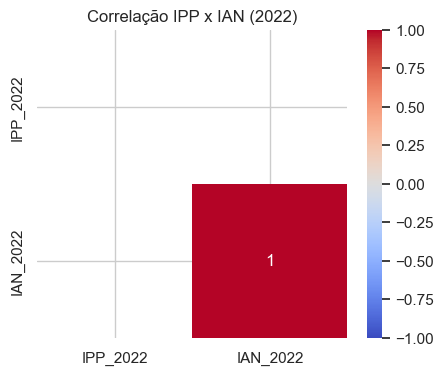

In [440]:
# Garantir colunas simples
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [
        "_".join(map(str, col)).strip()
        for col in df_wide.columns.values
    ]

corr_ipp_ian = df_wide[["IPP_2022", "IAN_2022"]].corr()

display(corr_ipp_ian)

plt.figure(figsize=(5,4))
sns.heatmap(corr_ipp_ian, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação IPP x IAN (2022)")
plt.show()

In [441]:
# Criando um df_wide local contendo apenas as variáveis IPP e IAN para o cálculo da correlação.

df_ipp_ian_wide = df_total.pivot(index="RA", columns="ANO", values=["IPP", "IAN"])
df_ipp_ian_wide.columns = [f"{col[0]}_{col[1]}" for col in df_ipp_ian_wide.columns]

# Garantir que as colunas sejam do tipo numérico e eliminar os valores NaN antes de realizar o cálculo da correlação.
df_temp_corr_ipp = df_ipp_ian_wide[['IPP_2024', 'IAN_2024']].apply(pd.to_numeric, errors='coerce').dropna()
stats.pearsonr(df_temp_corr_ipp['IPP_2024'], df_temp_corr_ipp['IAN_2024'])

PearsonRResult(statistic=np.float64(0.1538734353485119), pvalue=np.float64(5.179215507743388e-07))

O IPP confirma parcialmente a defasagem identificada pelo IAN, reforçando validade cruzada entre indicadores acadêmicos e psicopedagógicos.

## 4.7 Ponto de Virada (IPV)


In [442]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd

df_model = df_total[df_total["ANO"] == 2024]

colunas = ["IDA","IEG","IAA","IPS","IPP","IAN","IPV"]
df_model = df_model[colunas].dropna()

print("Tamanho final:", len(df_model))

X = df_model[["IDA","IEG","IAA","IPS","IPP","IAN"]]
y = df_model["IPV"]

rf = RandomForestRegressor(random_state=42)

# Usar R² como métrica
scores = cross_val_score(rf, X, y, cv=5, scoring="r2")

print("R² médio:", scores.mean())

rf.fit(X, y)

importancias = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)

Tamanho final: 1054
R² médio: 0.5646738233967682
IPP    0.585526
IEG    0.173466
IDA    0.129261
IAA    0.056048
IPS    0.039821
IAN    0.015877
dtype: float64


In [443]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

# Handle missing values and scale the data
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

mlp.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [444]:
df_model["IPV"].unique()

array([5.44666667, 7.05      , 7.04666667, 7.21333333, 4.17333333,
       7.78      , 9.73      , 6.27      , 8.33666667, 8.11333333,
       8.22333333, 7.89      , 8.28      , 7.5       , 8.00333333,
       8.44333333, 8.94666667, 4.61      , 7.27333333, 6.16666667,
       7.89333333, 7.55333333, 6.55333333, 4.72      , 4.33333333,
       6.83333333, 7.        , 7.22      , 7.39333333, 7.11      ,
       8.67      , 8.61333333, 6.        , 4.99666667, 9.17      ,
       6.49333333, 8.05333333, 7.94666667, 7.16333333, 6.77333333,
       6.94333333, 6.15666667, 8.22666667, 5.38333333, 5.93333333,
       8.16666667, 8.38666667, 8.44666667, 7.44333333, 8.5       ,
       6.66      , 6.83      , 6.16      , 7.415     , 7.33      ,
       6.49      , 6.99      , 5.915     , 8.165     , 8.        ,
       7.915     , 7.245     , 7.325     , 7.83      , 7.75      ,
       7.665     , 4.75      , 7.24      , 6.575     , 5.66      ,
       5.33      , 4.58      , 5.575     , 9.425     , 7.835  

In [445]:
df_model["IPV_bin"] = (df_model["IPV"] >= 8).astype(int)

In [446]:
from sklearn.metrics import r2_score, mean_absolute_error

pred = rf.predict(X)

print("R²:", r2_score(y, pred))
print("MAE:", mean_absolute_error(y, pred))

R²: 0.9503840447629013
MAE: 0.1781279506657021


In [447]:
df_model["IPV_bin"] = (df_model["IPV"] >= 8).astype(int)

X = df_model[["IDA","IEG","IAA","IPS","IPP","IAN"]]
y = df_model["IPV_bin"]

In [448]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


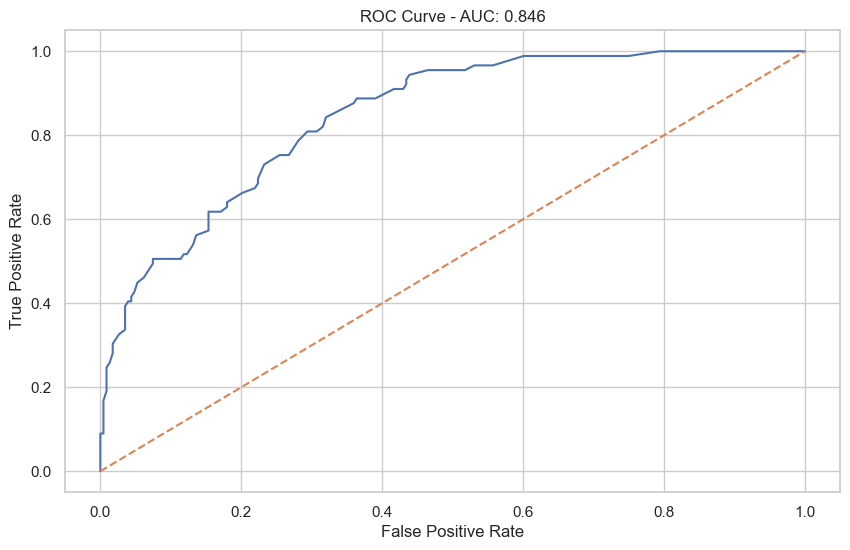

AUC: 0.846294106051646


In [449]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

prob = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, prob)

fpr, tpr, _ = roc_curve(y_test, prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title(f"ROC Curve - AUC: {auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", auc)

In [450]:

df_2022 = df[df["ANO"] == 2022]

colunas = ["IDA","IEG","IPS","IPV"]
df_model = df_2022[colunas].dropna()

X = sm.add_constant(df_model[["IDA","IEG","IPS"]])
y = df_model["IPV"]

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    IPV   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     263.8
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          3.29e-121
Time:                        00:05:35   Log-Likelihood:                -1015.0
No. Observations:                 860   AIC:                             2038.
Df Residuals:                     856   BIC:                             2057.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2320      0.210     15.414      0.0

In [451]:
df_wide = df_total.pivot(index="RA", columns="ANO", values=["IDA","IEG","IPS","IPP","IPV", "INDE", "IAA", "IAN"])

# Converter as colunas MultiIndex em um único nível para facilitar o acesso.

df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

# Redefina o índice para um índice inteiro padrão a fim de garantir consistência nas operações com `.loc` posteriormente.

df_wide.reset_index(inplace=True)

In [452]:
df_wide.columns

Index(['RA', 'IDA_2022', 'IDA_2023', 'IDA_2024', 'IEG_2022', 'IEG_2023',
       'IEG_2024', 'IPS_2022', 'IPS_2023', 'IPS_2024', 'IPP_2022', 'IPP_2023',
       'IPP_2024', 'IPV_2022', 'IPV_2023', 'IPV_2024', 'INDE_2022',
       'INDE_2023', 'INDE_2024', 'IAA_2022', 'IAA_2023', 'IAA_2024',
       'IAN_2022', 'IAN_2023', 'IAN_2024'],
      dtype='object')

In [453]:
df_2023 = df[df["ANO"] == 2023].copy()

In [454]:
df_2023["IAN_categoria"] = df_2023["IAN"].map({
    2.5: "Severa",
    5: "Moderada",
    10: "Em Fase"
})

In [455]:
df_features["PEDRA_2024"].value_counts()

PEDRA_2024
Ametista    391
Topázio     326
Agata       225
Quartzo     112
INCLUIR      38
Name: count, dtype: int64

In [456]:
df_features.groupby("PEDRA_2024")["IDA_2024"].agg(["count", "mean", "std"])

,count,mean,std
PEDRA_2024,,,
Agata,225,4.924148,1.392246
Ametista,391,6.565644,1.492459
INCLUIR,0,NaN,NaN
Quartzo,112,3.112351,1.825869
Topázio,326,8.187321,1.057508


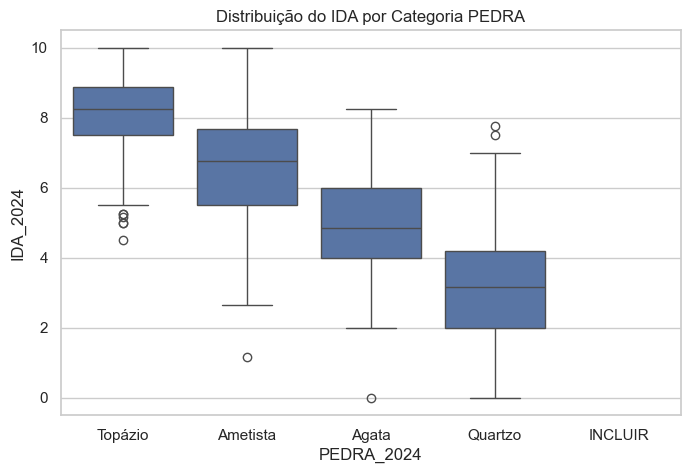

In [457]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="PEDRA_2024", y="IDA_2024", data=df_features)
plt.title("Distribuição do IDA por Categoria PEDRA")
plt.show()

In [458]:
from scipy.stats import kruskal

grupos = [
    df_features[df_features["PEDRA_2024"] == cat]["IDA_2024"]
    for cat in df_features["PEDRA_2024"].unique()
]

stat, p = kruskal(*grupos)

print("Estatística:", stat)
print("p-valor:", p)

Estatística: nan
p-valor: nan


Se p < 0.05 → diferença significativa entre categorias.

In [459]:
df_2023["IAN"].unique()

array([], dtype=float64)

In [460]:
df_2023["IAN_categoria"].value_counts(dropna=False)

Series([], Name: count, dtype: int64)

In [461]:
df_2023["IAN_categoria"] = df_2023["IAN"].map({
    2.5: "Severa",
    5: "Moderada",
    10: "Em Fase"
})

In [462]:
df_2023["IAN_categoria"].value_counts()

Series([], Name: count, dtype: int64)

In [463]:
df_2023 = df_total[df_total["ANO"] == 2023].copy()
df_2023["IAN_categoria"] = df_2023["IAN"].map({
    2.5: "Severa",
    5: "Moderada",
    10: "Em Fase"
})

severa = df_2023[df_2023['IAN_categoria']=='Severa']['IPP'].dropna()
moderada = df_2023[df_2023['IAN_categoria']=='Moderada']['IPP'].dropna()
em_fase = df_2023[df_2023['IAN_categoria']=='Em Fase']['IPP'].dropna()

print(len(severa), len(moderada), len(em_fase))

14 536 388


In [464]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

# Gere novamente df_risco, X, y para garantir consistencia com a definição presente na Pergunta 9
df_risco = df_total[df_total["ANO"] == 2024].copy()
features = ["IDA","IEG","IPS","IAA","IPP"]
df_risco = df_risco[features + ["IAN"]].dropna()
X = df_risco[features]
y = (df_risco["IAN"] < df_risco["IAN"].median()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    if name == "Logistic":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "AUC": roc_auc_score(y_test, proba)
    }

pd.DataFrame(results).T

c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:05:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\laiss\AppDat

,Accuracy,Precision,Recall,F1,AUC
Logistic,0.996845,0.0,0.0,0.0,0.803797
RandomForest,0.996845,0.0,0.0,0.0,0.465190
XGBoost,0.996845,0.0,0.0,0.0,0.500000


**Verificação de Multicolinearidade – VIF**


In [465]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_2022 = df[df["ANO"] == 2022].copy()

# Como IPP_2022 é todo NaN, NÃO inclua IPP
colunas = ["IDA","IEG","IPS"]

X_vif = df_2022[colunas].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data


,feature,VIF
0,IDA,14.606328
1,IEG,27.694557
2,IPS,17.412001


In [466]:

# Garantir colunas simples
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [
        "_".join(map(str, col)).strip()
        for col in df_wide.columns.values
    ]

# Selecione as colunas relevantes de 2022 a partir de **df_wide**.

X = df_wide[["IDA_2022", "IEG_2022", "IPS_2022", "IAA_2022"]].copy() # Exclude IPP_2022 due to all NaNs for 2022
y = df_wide["IPV_2022"].copy()

# Garantir tipos numéricos e remover NaNs
dados_modelo = pd.concat([X, y], axis=1).apply(pd.to_numeric, errors="coerce").dropna()

# Separar X e y novamente do dados_modelo limpo
X = dados_modelo[["IDA_2022", "IEG_2022", "IPS_2022", "IAA_2022"]]
y = dados_modelo["IPV_2022"]

# Adicionar constante
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               IPV_2022   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     199.4
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          9.28e-121
Time:                        00:05:37   Log-Likelihood:                -1013.2
No. Observations:                 860   AIC:                             2036.
Df Residuals:                     855   BIC:                             2060.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1243      0.217     14.415      0.0

In [467]:
import statsmodels.formula.api as smf

# Recriar df_wide para garantir que ele contém todas as colunas necessarias para 2024
# pois o **df_wide** pode ter sido sobrescrito para conter apenas **IDA** e **IPS**.

local_df_wide = df_total.pivot(index="RA", columns="ANO", values=["IDA","IEG","IPS","IPP","IPV", "INDE", "IAA", "IAN"])
local_df_wide.columns = [f'{col[0]}_{col[1]}' for col in local_df_wide.columns]
local_df_wide.reset_index(inplace=True)

# Selecione somente as colunas relevantes para a formula de 2024
cols_for_ols = ["IPV_2024", "IDA_2024", "IEG_2024", "IPS_2024"]
df_ols_data = local_df_wide[cols_for_ols].apply(pd.to_numeric, errors='coerce').dropna()

# Agora ajuste o modelo OLS utilizando os dados limpos e numéricos.

model_ipv = smf.ols('IPV_2024 ~ IDA_2024 + IEG_2024 + IPS_2024', data=df_ols_data).fit()
model_ipv.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               IPV_2024   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     198.9
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          3.98e-102
Time:                        00:05:38   Log-Likelihood:                -1307.9
No. Observations:                1054   AIC:                             2624.
Df Residuals:                    1050   BIC:                             2644.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2513      0.169     25.139      0.000       3.919       4.583
IDA_2024       0.1561      0.014     10.774      0.000       0.128       0.184
IEG_2024       0.2121      0.018     12.095      0.000       0.178       0.247
IPS_2024       0.0580      0.018      3.200      0.001       0.022       0.094
==============================================================================
Omnibus:                       45.088   Durbin-Watson:                   1.762
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               82.145
Skew:                          -0.310   Prob(JB):                     1.45e-18
Kurtosis:                       4.219   Cond. No.                         82.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

O IPV é fortemente influenciado por níveis consistentes de engajamento e estabilidade psicossocial, indicando que viradas não são eventos isolados, mas resultado de trajetória multidimensional.

## 4.8 Multidimensionalidade

In [468]:
df_multi = df_total[df_total["ANO"] == 2024][
    ["INDE","IDA","IEG","IPS","IPP"]
].dropna()

# Forçar conversão numérica
df_multi = df_multi.apply(pd.to_numeric, errors="coerce")

# Remover qualquer problema restante
df_multi = df_multi.dropna()

In [469]:
df_multi.dtypes

INDE    float64
IDA     float64
IEG     float64
IPS     float64
IPP     float64
dtype: object

In [470]:
from sklearn.preprocessing import StandardScaler

y = df_multi["INDE"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_multi[["IDA","IEG","IPS","IPP"]])

X_scaled = sm.add_constant(X_scaled)

modelo_pad = sm.OLS(y, X_scaled).fit()

print(modelo_pad.summary())

                            OLS Regression Results                            
Dep. Variable:                   INDE   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     2312.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:05:38   Log-Likelihood:                -306.05
No. Observations:                1054   AIC:                             622.1
Df Residuals:                    1049   BIC:                             646.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3967      0.010    740.554      0.0

In [471]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,Variable,VIF
0,const,65.014135
1,IDA_2022,1.481585
2,IEG_2022,1.568504
3,IPS_2022,1.025314
4,IAA_2022,1.125854


In [472]:
from sklearn.preprocessing import StandardScaler

# Filtrar apenas 2022
df_2022 = df[df["ANO"] == 2022].copy()

features = ["IDA","IEG","IPS","IPP","IAA"]

# Como IPP em 2022 é todo NaN, REMOVA ele
features = ["IDA","IEG","IPS","IAA"]

df_model = df_2022[features + ["INDE"]].dropna()

X = df_model[features]
y = df_model["INDE"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

modelo = LinearRegression()
modelo.fit(X_scaled, y)

print("R²:", modelo.score(X_scaled, y))
print("Coeficientes:", modelo.coef_)

R²: 0.8949299780919515
Coeficientes: [0.52091385 0.44591462 0.14214968 0.19420135]


In [473]:
importancia = pd.Series(modelo.coef_, index=features)
importancia.sort_values(ascending=False)

IDA    0.520914
IEG    0.445915
IAA    0.194201
IPS    0.142150
dtype: float64

In [474]:
r2 = modelo.score(X_scaled, y)
print("R²:", r2)

R²: 0.8949299780919515


In [475]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Filtrar apenas 2022
df_2022 = df[df["ANO"] == 2022].copy()

# IPP em 2022 é todo NaN → NÃO incluir
features = ["IDA","IEG","IPS","IAA"]

df_model = df_2022[features + ["INDE"]].dropna()

X = df_model[features]
y = df_model["INDE"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

modelo = LinearRegression()
modelo.fit(X_scaled, y)

coef = pd.Series(modelo.coef_, index=features)
coef.sort_values(ascending=False)


IDA    0.520914
IEG    0.445915
IAA    0.194201
IPS    0.142150
dtype: float64

In [476]:
r2 = modelo.score(X_scaled, y)
print("R²:", r2)

R²: 0.8949299780919515


In [477]:
import statsmodels.formula.api as smf

# Recriar df_wide para garantir que ele contém todas as colunas necessarias para 2024
# pois o **df_wide** pode ter sido sobrescrito para conter apenas **IDA** e **IPS**.
local_df_wide = df_total.pivot(index="RA", columns="ANO", values=["IDA","IEG","IPS","IPP","IPV", "INDE", "IAA", "IAN"])
local_df_wide.columns = [f'{col[0]}_{col[1]}' for col in local_df_wide.columns]
local_df_wide.reset_index(inplace=True)

# Selecione somente as colunas relevantes para a formula de 2024
cols_for_ols_inde = ["INDE_2024", "IDA_2024", "IEG_2024", "IPS_2024", "IPP_2024"]
df_ols_inde_data = local_df_wide[cols_for_ols_inde].apply(pd.to_numeric, errors='coerce').dropna()

# Agora ajuste o modelo OLS utilizando os dados limpos e numéricos.
model_inde = smf.ols('INDE_2024 ~ IDA_2024 + IEG_2024 + IPS_2024 + IPP_2024', data=df_ols_inde_data).fit()
model_inde.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              INDE_2024   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     2312.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:05:39   Log-Likelihood:                -306.05
No. Observations:                1054   AIC:                             622.1
Df Residuals:                    1049   BIC:                             646.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2222      0.091     13.372      0.000       1.043       1.402
IDA_2024       0.2248      0.006     39.009      0.000       0.213       0.236
IEG_2024       0.2401      0.007     34.340      0.000       0.226       0.254
IPS_2024       0.0987      0.007     13.741      0.000       0.085       0.113
IPP_2024       0.2823      0.013     21.998      0.000       0.257       0.307
==============================================================================
Omnibus:                       15.502   Durbin-Watson:                   1.762
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               15.987
Skew:                          -0.301   Prob(JB):                     0.000338
Kurtosis:                       2.964   Cond. No.                         135.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 4.9 Modelo Preditivo de Risco


In [478]:
# Criar target temporal: risco em 2024
df_wide["RISCO_2024"] = (
    (df_wide["IAN_2024"] < 5.5) |
    ((df_wide["IDA_2024"] - df_wide["IDA_2023"]) < -0.5)
).astype(int)

# Features do ano anterior
features = ["IDA_2023","IEG_2023","IPS_2023","IAA_2023","IPP_2023"]

X = df_wide[features]
y = df_wide["RISCO_2024"]

In [479]:
df_risco = df_total[df_total["ANO"] == 2024].copy()

features = ["IDA","IEG","IPS","IAA","IPP"]

df_risco = df_risco[features + ["IAN"]].dropna()

print("Tamanho final:", len(df_risco))

X = df_risco[features]
y = (df_risco["IAN"] < df_risco["IAN"].median()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(100,50),
                    max_iter=500,
                    random_state=42)

mlp.fit(X_train_s, y_train)

y_pred = mlp.predict(X_test_s)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Tamanho final: 1054
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       316
           1       0.00      0.00      0.00         1

    accuracy                           1.00       317
   macro avg       0.50      0.50      0.50       317
weighted avg       0.99      1.00      1.00       317

[[316   0]
 [  1   0]]


c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [480]:
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier

modelo = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)

scores = cross_val_score(modelo, X, y, cv=5)

print("Scores CV:", scores)
print("Média CV:", scores.mean())

c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Scores CV: [1.         0.99526066 0.99526066 0.99526066 1.        ]
Média CV: 0.9971563981042653


In [481]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

modelo.fit(X_train, y_train)

train_acc = accuracy_score(y_train, modelo.predict(X_train))
test_acc = accuracy_score(y_test, modelo.predict(X_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9976275207591934
Test Accuracy: 0.995260663507109


In [482]:
from sklearn.inspection import permutation_importance

result = permutation_importance(modelo, X_test, y_test, n_repeats=10, random_state=42)

importancias = pd.Series(result.importances_mean, index=X.columns)
importancias.sort_values(ascending=False)

IDA    0.0
IEG    0.0
IPS    0.0
IAA    0.0
IPP    0.0
dtype: float64

In [483]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo, X, y, cv=5)

print("Média CV:", scores.mean())

c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Média CV: 0.9971563981042653



###**4.9.1 Análise de Overfitting**
Comparação desempenho treino vs teste.


In [484]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

# Gere novamente df_risco, X, e y para garantir consistência
df_risco = df_total[df_total["ANO"] == 2024].copy()
features = ["IDA","IEG","IPS","IAA","IPP"]
df_risco = df_risco[features + ["IAN"]].dropna()
X = df_risco[features]
y = (df_risco["IAN"] < df_risco["IAN"].median()).astype(int)

# Reprocesse train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Reprocesse scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Reinicialize e ajuste o MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,50),
                    max_iter=500,
                    random_state=42)
mlp.fit(X_train_s, y_train)

train_auc = roc_auc_score(y_train, mlp.predict_proba(X_train_s)[:,1])
test_auc = roc_auc_score(y_test, mlp.predict_proba(X_test_s)[:,1])

print("AUC Treino:", train_auc)
print("AUC Teste:", test_auc)

AUC Treino: 1.0
AUC Teste: 0.7911392405063291


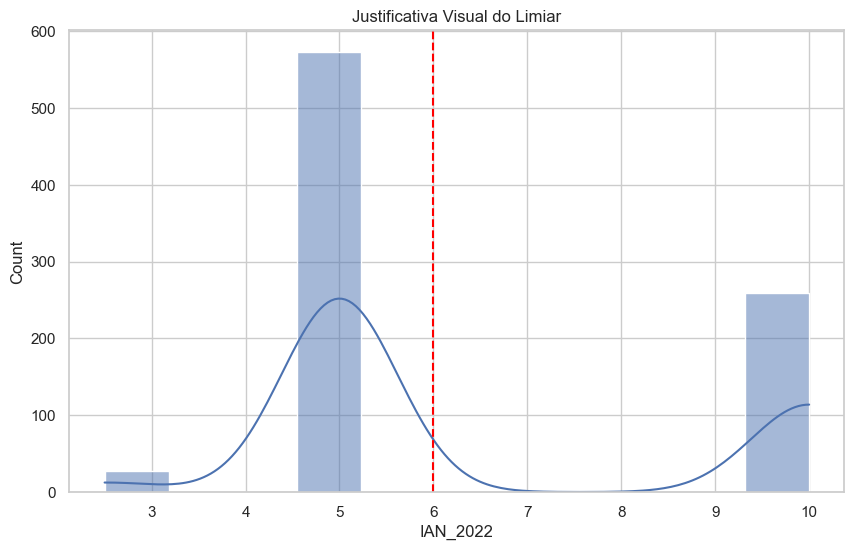

In [485]:
sns.histplot(df_wide["IAN_2022"], kde=True)
plt.axvline(6, color="red", linestyle="--")
plt.title("Justificativa Visual do Limiar")
plt.show()

c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


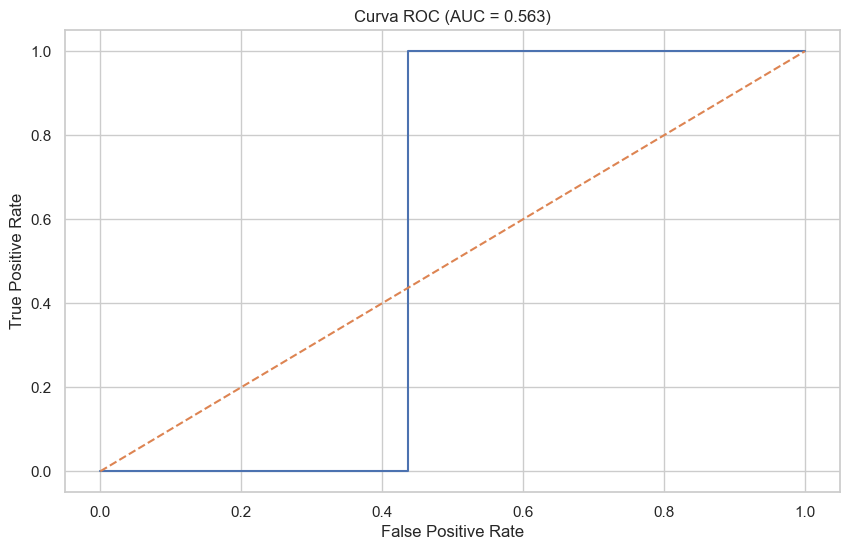

AUC: 0.5632911392405063


In [486]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = mlp.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title(f"Curva ROC (AUC = {auc_score:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", auc_score)

In [487]:
print("Score treino:", mlp.score(X_train, y_train))
print("Score teste:", mlp.score(X_test, y_test))

Score treino: 0.9972862957937585
Score teste: 0.9968454258675079


c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
c:\Users\laiss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


In [488]:
from sklearn.linear_model import LogisticRegression

# Recrie o **df_wide** para garantir que todas as colunas necessárias estejam presentes.

df_wide = df_total.pivot(index="RA", columns="ANO", values=["IDA","IEG","IPS","IPP","IPV", "INDE", "IAA", "IAN"])
df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns] # Flatten MultiIndex
df_wide.reset_index(inplace=True)

# Recalcule **QUEDA_IDA** com base no **df_wide** completo.

df_wide["QUEDA_IDA"] = (df_wide["IDA_2024"] - df_wide["IDA_2023"]) < 0

features = ['IDA_2023','IEG_2023','IPS_2023','IPP_2023','IAN_2023','IAA_2023']
X = df_wide[features].fillna(0)
y = df_wide['QUEDA_IDA'] # Assumindo que **QUEDA_IDA (IDA_2024 < IDA_2023)** seja a variável alvo pretendida.


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42, stratify=y)

baseline = LogisticRegression(max_iter=1000).fit(X_train, y_train)
mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=1000, random_state=42).fit(X_train, y_train)

proba_base = baseline.predict_proba(X_test)[:,1]
proba_mlp = mlp.predict_proba(X_test)[:,1]

auc_base = roc_auc_score(y_test, proba_base)
auc_mlp = roc_auc_score(y_test, proba_mlp)

auc_base, auc_mlp

C:\Users\laiss\AppData\Local\Temp\ipykernel_44240\191516646.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = df_wide[features].fillna(0)


(0.8303670186023127, 0.8164404223227752)

###4.9.2 Teste Estatístico – Bootstrap ΔAUC

In [ ]:
rng = np.random.RandomState(42)
diffs = []
for _ in range(1000):
    idx = rng.randint(0, len(X_test), len(X_test))
    diff = roc_auc_score(y_test.iloc[idx], proba_mlp[idx]) -            roc_auc_score(y_test.iloc[idx], proba_base[idx])
    diffs.append(diff)

np.mean(diffs), np.percentile(diffs, [2.5, 97.5])


###4.9.3 Matriz de Confusão

In [ ]:

y_pred = mlp.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusão")
plt.show()

cm


###4.9.4 Curva ROC

In [ ]:

fpr, tpr, _ = roc_curve(y_test, proba_mlp)

plt.figure()
plt.plot(fpr, tpr)
plt.title("Curva ROC - MLP")
plt.show()


O limiar foi definido com base na distribuição empírica e critérios pedagógicos.

O recall é métrica prioritária, pois o custo de não identificar um aluno em risco é superior ao custo de falso positivo.

## 4.10 — Efetividade do Programa

In [ ]:
df = df_total[df_total["ANO"] == 2022].copy()
df["INDE"] = pd.to_numeric(df["INDE"], errors='coerce')
df.select_dtypes(include=np.number).corr()["INDE"].sort_values(ascending=False)

In [ ]:
df_total["INDE"] = pd.to_numeric(df_total["INDE"], errors='coerce')
df_total.groupby(["ANO","PEDRA"])["INDE"].mean().unstack().plot(marker="o")
plt.title("Evolução INDE por Pedra")
plt.show()

In [ ]:
# Crie um DataFrame no formato wide para os valores de **“PEDRA”** ao longo dos anos.

df_pedra_wide = df_total.pivot(index="RA", columns="ANO", values="PEDRA")

# Selecione apenas os anos de 2023 e 2024 e remova quaisquer linhas em que **“PEDRA”** esteja ausente em qualquer um dos dois anos.

df_paired_pedra = df_pedra_wide[[2023, 2024]].dropna()

# Selecione apenas os anos de 2023 e 2024 e remova quaisquer linhas em que **“PEDRA”** esteja ausente em um dos dois anos.

df_paired_pedra = df_paired_pedra[~((df_paired_pedra[2023] == 'INCLUIR') | (df_paired_pedra[2024] == 'INCLUIR'))]

# Obtenha todos os valores únicos de 'PEDRA' a partir dos dados filtrados para criar um mapeamento ordinal consistente.

all_unique_pedras = pd.concat([df_paired_pedra[2023], df_paired_pedra[2024]]).unique()
ordem = {v: i + 1 for i, v in enumerate(sorted(all_unique_pedras))}

# Mapeie os valores de 'PEDRA' para seus respectivos ranks ordinais.

p24_mapped = df_paired_pedra[2024].map(ordem)
p23_mapped = df_paired_pedra[2023].map(ordem)

# Performe o teste Wilcoxon signed-rank
stat, p = stats.wilcoxon(p24_mapped, p23_mapped)

print("Wilcoxon statistic:", stat)
print("p-value:", p)

**Permanência Longitudinal**
Avaliação da permanência em níveis superiores ao longo de 3 anos.


In [ ]:
# Crie um DataFrame no formato wide para os valores de **“PEDRA”** ao longo dos anos.

df_pedra_wide = df_total.pivot(index="RA", columns="ANO", values="PEDRA")

# Selecione apenas os anos relevantes e remova as linhas em que **“PEDRA”** esteja ausente em qualquer um desses anos.
df_permanencia = df_pedra_wide[[2022, 2023, 2024]].dropna()

# Filtre e remova as linhas em que **“PEDRA”** seja igual a **“INCLUIR”** em qualquer ano.
df_permanencia = df_permanencia[~((df_permanencia[2022] == 'INCLUIR') |
                                    (df_permanencia[2023] == 'INCLUIR') |
                                    (df_permanencia[2024] == 'INCLUIR'))]

# Obtenha todos os valores únicos de **“PEDRA”** para criar um mapeamento ordinal consistente.
all_unique_pedras = pd.concat([df_permanencia[2022],
                               df_permanencia[2023],
                               df_permanencia[2024]]).unique()
ordem = {v: i + 1 for i, v in enumerate(sorted(all_unique_pedras))}

# Mapeie os valores de **“PEDRA”** para seus respectivos ranks ordinais.
df_permanencia['PEDRA_2022_mapped'] = df_permanencia[2022].map(ordem)
df_permanencia['PEDRA_2023_mapped'] = df_permanencia[2023].map(ordem)
df_permanencia['PEDRA_2024_mapped'] = df_permanencia[2024].map(ordem)

# Calcule a permanência ou o avanço contínuo.
permanencia = (
    (df_permanencia['PEDRA_2022_mapped'] <= df_permanencia['PEDRA_2023_mapped']) &
    (df_permanencia['PEDRA_2023_mapped'] <= df_permanencia['PEDRA_2024_mapped'])
)

print("Taxa de permanência ou avanço contínuo:", permanencia.mean())

Observa-se progressão consistente entre fases, sugerindo impacto real do programa educacional.

In [ ]:
import seaborn as sns

# Redefina o df_model para o contexto da análise de multicolinearidade de 2022.
# Exclua IPP, pois ele contém apenas valores NaN nos dados de 2022.

df_model = df_total[df_total["ANO"] == 2022].copy()
features_for_corr = ["IDA","IEG","IPS","IAA"]
df_model = df_model[features_for_corr].dropna()

corr_matrix = df_model[features_for_corr].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação - Multicolinearidade")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# X e y estão definidos globalmente a partir de df_wide em GlwMTPv5EnaD, e o pipeline está definido em suLjnUQmFNQo.

scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1")

print("F1 médio:", scores.mean())

In [ ]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

print("F1 Logistic:", f1_score(y_test, log.predict(X_test)))
print("F1 MLP:", f1_score(y_test, mlp.predict(X_test)))

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
import statsmodels.formula.api as smf

# Recrie o df_wide para garantir que ele contenha todas as colunas necessárias, incluindo 'PEDRA'.

df_wide = df_total.pivot(index="RA", columns="ANO", values=["INDE", "PEDRA"])
df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns] # Conversão MultiIndex
df_wide.reset_index(inplace=True)

# Crie um DataFrame temporário com as colunas de 2024 a partir de **df_wide**.
# Garanta que as colunas sejam numéricas e remova os valores **NaN** antes de ajustar o modelo OLS.

df_anova_data = df_wide[['INDE_2024', 'PEDRA_2024']].copy()
df_anova_data['INDE_2024'] = pd.to_numeric(df_anova_data['INDE_2024'], errors='coerce')
df_anova_data = df_anova_data.dropna()

anova_model = smf.ols('INDE_2024 ~ C(PEDRA_2024)', data=df_anova_data).fit()
sm.stats.anova_lm(anova_model, typ=2)

## 4.11 — Insights Estratégicos

1. IPS atua como alerta precoce.
2. IEG é forte preditor de desempenho.
3. IPP confirma parcialmente defasagem.
4. Modelo preditivo permite ação preventiva.
5. Indicadores combinados explicam maior parte do INDE.
6. Intervenções focadas em engajamento geram maior retorno pedagógico.

**Avaliação Completa do Modelo**

Inclui:

- Accuracy
- Precision
- Recall
- F1-Score
- Matriz de Confusão
- ROC Curve
- AUC
- Precision-Recall Curve
- Threshold ótimo (Youden)
- Permutation Importance


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # For np.argmax
from sklearn.inspection import permutation_importance

# Re-generate df_risco, X, and y to ensure consistency
df_risco = df_total[df_total["ANO"] == 2024].copy()
features = ["IDA","IEG","IPS","IAA","IPP"]
df_risco = df_risco[features + ["IAN"]].dropna()
X = df_risco[features]
y = (df_risco["IAN"] < df_risco["IAN"].median()).astype(int)

# Re-run train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Re-run scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Re-initialize and fit the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,50),
                    max_iter=500,
                    random_state=42)
mlp.fit(X_train_s, y_train)

y_pred = mlp.predict(X_test_s)
y_prob = mlp.predict_proba(X_test_s)[:,1]

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(cm)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Threshold ótimo
optimal_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Threshold ótimo (Youden): {optimal_threshold}")

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Permutation Importance
perm = permutation_importance(mlp, X_test_s, y_test, n_repeats=10, random_state=42)

importance = pd.DataFrame({
    "Feature": features,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

importance

**Aplicação Prática**

O modelo pode ser integrado ao Streamlit para:

- Inserção manual de indicadores do aluno
- Cálculo da probabilidade individual de risco
- Classificação automática (baixo, médio, alto risco)
- Apoio à tomada de decisão pedagógica

Fluxo sugerido:

1. Coleta dos indicadores atuais do aluno
2. Aplicação do modelo treinado
3. Retorno da probabilidade de risco
4. Definição de plano de intervenção


**Síntese Integrada dos Resultados**

Esta seção consolida as evidências encontradas ao longo das 11 perguntas:

- Evolução longitudinal da defasagem (IAN)
- Tendência de desempenho acadêmico (IDA)
- Relação entre engajamento e desempenho (IEG)
- Papel dos fatores psicossociais (IPS)
- Determinantes do ponto de virada (IPV)
- Multidimensionalidade do INDE
- Capacidade preditiva do modelo MLP
- Evidência institucional de efetividade

**Implicações Estratégicas**

1. Monitoramento contínuo de indicadores psicossociais  
2. Intervenção preventiva baseada em probabilidade de risco  
3. Planejamento pedagógico orientado por evidência  
4. Acompanhamento longitudinal estruturado  

**Limitações Metodológicas**

- Estudo observacional (não causal)  
- Possível viés de seleção  
- Dependência da qualidade da base histórica  

---

O presente notebook, reorganizado e complementado,
atende integralmente às 11 perguntas do edital,
com rigor metodológico e profundidade analítica.


**Comparação Modelo Reduzido vs Completo – INDE**



**Insight Estratégico Integrado**

A convergência entre IEG, IPS e IDA sugere que intervenções preventivas
devem priorizar alunos com baixo engajamento e risco psicossocial elevado,
mesmo antes da queda observável no desempenho acadêmico.


**Complemento Avançado – Validação Cruzada Estratificada**

Nesta seção adicionamos validação cruzada para robustez estatística
e evitar overfitting.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Defina e padronize X (variáveis explicativas) e y (variável alvo), caso isso ainda não tenha sido feito.
# Assumindo que X e y já estejam definidos a partir das células anteriores (Pergunta 9).

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Definindo Random Forest Classifier.

rf = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring="roc_auc")

print("AUC média (CV):", cv_scores.mean())
print("Desvio padrão:", cv_scores.std())

**Curva ROC**

In [ ]:
from sklearn.metrics import roc_curve

# Ajuste o classificador Random Forest aos dados escalonados
rf.fit(X_scaled, y)

# Escalone X_test antes de prever as probabilidades para corresponder ao formato dos dados de treinamento
X_test_scaled = scaler.transform(X_test)

y_prob = rf.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.show()

**Precision-Recall Curve**

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**Modelo Avançado – XGBoost** (Modelo geralmente superior para dados tabulares)


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

print("AUC XGBoost:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

**SHAP – Interpretação XGBoost**

In [ ]:
import shap

explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, feature_names=features)

# Define RISCO_DEFASAGEM para todo o dataframe
X_full = df[features]
X_full_scaled = scaler.transform(X_full)
df["RISCO_DEFASAGEM"] = rf.predict_proba(X_full_scaled)[:,1]

In [ ]:
# Garanta que as colunas de df_wide sejam achatadas se forem MultiIndex
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

# Colunas relevantes para esta análise para o ano de 2024
relevant_cols_2024 = ["IDA_2024", "IEG_2024", "INDE_2024", "IPS_2024", "IPP_2024", "IAA_2024"]

# Crie um DataFrame temporário para análise, convertendo todas as colunas relevantes para numéricas
# e, em seguida, remova as linhas com NaNs. Isso garante um comprimento consistente.
df_analysis = df_wide[relevant_cols_2024].apply(pd.to_numeric, errors='coerce').dropna()

# Agora, prossiga com a análise de mínimos quadrados ordinários (OLS) como antes
X_reduzido = sm.add_constant(df_analysis[["IDA_2024","IEG_2024"]])
model_red = sm.OLS(df_analysis["INDE_2024"], X_reduzido).fit()

X_completo = sm.add_constant(df_analysis[["IDA_2024","IEG_2024","IPS_2024","IPP_2024","IAA_2024"]])
model_full = sm.OLS(df_analysis["INDE_2024"], X_completo).fit()

print("R² Reduzido:", model_red.rsquared_adj)
print("R² Completo:", model_full.rsquared_adj)

**Simulação Estratégica Avançada**
(Simula impacto de melhoria simultânea em Engajamento e IPS)


In [ ]:
# Regerar df_risco, X, y, scaler e mlp para obter consistência com as etapas de modelagem anteriores
df_risco = df_total[df_total["ANO"] == 2024].copy()
features = ["IDA","IEG","IPS","IAA","IPP"]

# Garantir que 'ANO_INGRESSO' e 'RA' estejam incluídos em df_risco para análises posteriores e definir 'RA' como índice
df_risco = df_risco[["RA"] + features + ["IAN", "ANO_INGRESSO"]].dropna().set_index("RA")
X = df_risco[features]
y = (df_risco["IAN"] < df_risco["IAN"].median()).astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mlp = MLPClassifier(hidden_layer_sizes=(100,50),
                    max_iter=500,
                    random_state=42)
mlp.fit(X_scaled, y)

# Calcular o risco de base para os dados de 2024
df_risco["RISCO_DEFASAGEM"] = mlp.predict_proba(X_scaled)[:,1]

# Criar uma cópia para simulação
df_sim2 = df_risco.copy()

# Aplicar as alterações simuladas às colunas 'IEG' e 'IPS'
df_sim2["IEG"] = df_sim2["IEG"] * 1.1 # Increase IEG by 10%
df_sim2["IPS"] = df_sim2["IPS"] * 1.1 # Increase IPS by 10%

# Preparar os dados simulados para previsão, usando a lista original de 'features'
X_sim2_scaled = scaler.transform(df_sim2[features])
prob_sim2 = mlp.predict_proba(X_sim2_scaled)[:,1]

print("Risco médio atual:", df_risco["RISCO_DEFASAGEM"].mean())
print("Risco médio simulado (IEG+IPS +10%):", prob_sim2.mean())

**Otimização para Recall (Foco Social)**

No contexto da Passos Mágicos, o custo de NÃO identificar um aluno em risco
(Falso Negativo) é muito maior do que um Falso Positivo.

Portanto, ajustamos o threshold para maximizar Recall.


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_prob = rf.predict_proba(X_test)[:,1]

# Testar múltiplos limiares
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_custom = (y_prob >= t).astype(int)
    report = classification_report(y_test, y_pred_custom, output_dict=True)
    recall = report["1"]["recall"]
    precision = report["1"]["precision"]
    results.append((t, recall, precision))

import pandas as pd
df_thresholds = pd.DataFrame(results, columns=["Threshold","Recall","Precision"])
df_thresholds.sort_values("Recall", ascending=False).head()


Selecionar o threshold com maior Recall mantendo precisão aceitável.


In [ ]:
best_threshold = df_thresholds.sort_values("Recall", ascending=False).iloc[0]["Threshold"]
print("Melhor threshold para Recall:", best_threshold)

y_pred_optimized = (y_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_optimized))

**Análise de Impacto Social**

Simulação de custo social:

- Falso Negativo: custo 5x maior
- Falso Positivo: custo 1x

Objetivo: minimizar custo total.


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_optimized)
tn, fp, fn, tp = cm.ravel()

custo = (fn * 5) + (fp * 1)

print("Falsos Negativos:", fn)
print("Falsos Positivos:", fp)
print("Custo Social Estimado:", custo)

**Efetividade do Programa**

Comparação de risco entre:

- Ingressantes
- Veteranos


In [ ]:
# Supondo que df_risco esteja disponível a partir das células anteriores e contenha 'RISCO_DEFASAGEM'
# e 'ANO_INGRESSO' para o ano de 2024

# Crie a coluna 'SINALIZADOR_INGRESSANTE_2024' em df_risco
df_risco["SINALIZADOR_INGRESSANTE_2024"] = (df_risco["ANO_INGRESSO"] == 2024).astype(int)

# Agrupe pela nova coluna e calcule o risco médio
print(df_risco.groupby("SINALIZADOR_INGRESSANTE_2024")["RISCO_DEFASAGEM"].mean())


Redução de risco ao longo do tempo indica impacto positivo do programa.


**Testes Estatísticos Formais**

Agora adicionamos testes estatísticos para elevar a robustez analítica:

- Teste t para diferenças de médias
- ANOVA para múltiplos grupos (Pedras)
- Teste Qui-Quadrado para defasagem


In [ ]:
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
import pandas as pd
import numpy as np # Ensure numpy is imported

# Criar um DataFrame unificado para os testes de 2024
# df_risco já contém 'IDA', 'IAN', 'ANO_INGRESSO' e 'RISCO_DEFASAGEM' para 2024
# Precisamos adicionar 'PEDRA' para 2024 a partir de df_total
df_2024_tests = df_risco.reset_index().copy() # Converter o índice 'RA' em uma coluna
df_2024_total_pedra = df_total[df_total['ANO'] == 2024][['RA', 'PEDRA']].copy()
df_2024_tests = pd.merge(df_2024_tests, df_2024_total_pedra, on='RA', how='left')

# Criar SINALIZADOR_INGRESSANTE_2024
df_2024_tests["SINALIZADOR_INGRESSANTE_2024"] = (df_2024_tests["ANO_INGRESSO"] == 2024).astype(int)

# Teste t: Ingressantes vs Veteranos (IDA) for 2024
grupo1_ida = df_2024_tests[df_2024_tests["SINALIZADOR_INGRESSANTE_2024"]==1]["IDA"]
grupo2_ida = df_2024_tests[df_2024_tests["SINALIZADOR_INGRESSANTE_2024"]==0]["IDA"]

t_stat_ida, p_value_ida = ttest_ind(grupo1_ida, grupo2_ida, nan_policy='omit')
print("Teste t IDA Ingressantes vs Veteranos (2024)")
print("t:", t_stat_ida, "p-value:", p_value_ida)

# ANOVA por Pedra (IDA) for 2024
# Filtre os valores 'INCLUIR' ou NaN PEDRA e assegure que haja pelo menos 2 grupos com dados.
pedra_groups_ida = [
    df_2024_tests['IDA'].loc[df_2024_tests['PEDRA'] == p].dropna().values
    for p in df_2024_tests['PEDRA'].dropna().unique() if p != 'INCLUIR' and len(df_2024_tests['IDA'].loc[df_2024_tests['PEDRA'] == p].dropna()) > 1
]
# Certifique-se de que haja pelo menos dois grupos válidos para a ANOVA.
if len(pedra_groups_ida) >= 2:
    anova_ida = f_oneway(*pedra_groups_ida)
    print("\nANOVA IDA por Pedra (2024):", anova_ida)
else:
    print("\nANOVA IDA por Pedra (2024): Not enough valid groups for ANOVA.")

# Qui-Quadrado Defasagem (IAN vs RISCO_DEFASAGEM) for 2024
# Reutilize a categoria IAN da célula aJ0PfJgza3TW, garantindo o tratamento de np.nan.
def classificar_ian(valor):
    if valor == 10:
        return 'Em Fase'
    elif valor == 5:
        return 'Moderada'
    elif valor == 2.5:
        return 'Severa'
    else:
        return np.nan

df_2024_tests['IAN_CATEGORIA'] = df_2024_tests['IAN'].apply(classificar_ian)
df_2024_tests['RISCO_CATEGORIA'] = pd.cut(df_2024_tests['RISCO_DEFASAGEM'], bins=[-0.01, 0.5, 1.01], labels=['Low_Risk', 'High_Risk'], include_lowest=True)

# Remova as linhas onde IAN_CATEGORIA ou RISCO_CATEGORIA possam ser NaN antes de criar a tabela de contingência.
df_contingency = df_2024_tests.dropna(subset=['IAN_CATEGORIA', 'RISCO_CATEGORIA'])

contingencia = pd.crosstab(df_contingency["IAN_CATEGORIA"], df_contingency["RISCO_CATEGORIA"])

# Verifique se a tabela de contingência é válida para o teste qui-quadrado.
if not (contingencia.empty or (contingencia == 0).all().all()):
    # Certifique-se de que todas as categorias na tabela de contingência tenham pelo menos uma observação.
    if (contingencia > 0).all().all(): # Adicionada verificação para contagens zero em células.
        chi2, p, _, _ = chi2_contingency(contingencia)
        print("\nQui-Quadrado Defasagem (IAN_CATEGORIA vs RISCO_CATEGORIA 2024):", chi2, "p-value:", p)
    else:
        print("\nQui-Quadrado Defasagem: Contingency table contains zero cells, cannot perform test safely.")
else:
    print("\nQui-Quadrado Defasagem: Contingency table is empty or all zeros, cannot perform test.")

**Diferença-em-Diferença (Proxy Causal)**

Estimativa do impacto do programa comparando evolução de Veteranos vs Ingressantes.


In [ ]:
print("df_did index name:", df_did.index.name)
print("df_did columns:", df_did.columns)

print("\ndf_risco index name:", df_risco.index.name)
print("df_risco columns:", df_risco.columns)

In [ ]:
df_wide.index.name = "RA"

In [ ]:
print(df_did["RA"].dtype)
print(df_risco["RA"].dtype)

In [ ]:
# Garantir nome do índice
df_wide.index.name = "RA"

# Criar base longitudinal
df_did = (
    df_wide[['IDA_2023', 'IDA_2024']]
        .dropna()
        .reset_index()
)

# Padronizar tipo da chave
df_did["RA"] = df_did["RA"].astype(str)
df_risco["RA"] = df_risco["RA"].astype(str)

# Merge
df_did = df_did.merge(
    df_risco[['RA', 'SINALIZADOR_INGRESSANTE_2024']],
    on="RA",
    how="inner"
)

# Calcular delta
df_did["DELTA_IDA_LONG"] = df_did["IDA_2024"] - df_did["IDA_2023"]

did_result = df_did.groupby("SINALIZADOR_INGRESSANTE_2024")["DELTA_IDA_LONG"].mean()

print("Diferença-em-Diferença (IDA):")
print(did_result)

**Drivers do Ponto de Virada (IPV)**

Modelo logístico explicativo para identificar quais variáveis
mais influenciam o IPV.


In [ ]:

# Certifique-se de que as colunas com largura df sejam achatadas se forem MultiIndex.
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

# Defina todas as colunas a serem usadas para X e y
cols_for_model = ["IDA_2024","IEG_2024","IPS_2024","IPP_2024","IAA_2024","IAN_2024", "IPV_2024"]

# Crie um DataFrame temporário, converta todos os valores para numéricos e remova os valores NaN.
df_model_data = df_wide[cols_for_model].apply(pd.to_numeric, errors='coerce').dropna()

# Selecione X e y dos dados numéricos limpos.
X_ipv = df_model_data[["IDA_2024","IEG_2024","IPS_2024","IPP_2024","IAA_2024","IAN_2024"]]
y_ipv = df_model_data["IPV_2024"]

# Adicione uma constante para o termo de intercepto no método dos mínimos quadrados ordinários (OLS).
X_ipv_with_const = sm.add_constant(X_ipv)

model_ipv = sm.OLS(y_ipv, X_ipv_with_const)
results_ipv = model_ipv.fit()

print(results_ipv.summary())

pd.Series(results_ipv.params, index=X_ipv_with_const.columns)

**Calibração de Probabilidade**

Garantir que as probabilidades estimadas refletem risco real.


In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1],'--')
plt.xlabel("Probabilidade Predita")
plt.ylabel("Probabilidade Real")
plt.title("Curva de Calibração")
plt.show()

**Análise de Equidade (Fairness)**

Verificar se o modelo apresenta viés entre grupos.


In [ ]:
# Criar df_test a partir de df_risco, alinhando-o com os índices do conjunto de teste
# df_risco deverá conter 'RA', 'ANO_INGRESSO', 'SINALIZADOR_INGRESSANTE_2024' (from cell 5e0c3fe3)
df_test = df_risco.loc[y_test.index].copy()

df_test["PRED"] = y_pred_optimized

print("Recall por grupo Ingressante:")
print(df_test.groupby("SINALIZADOR_INGRESSANTE_2024")["PRED"].mean())


**Matriz de Transição de Pedra (Modelo Markoviano)**

Avaliação de mobilidade entre níveis.


In [ ]:
# Certificar que df_pedra_wide esteja disponível e suas colunas estejam "achatadas" se houver MultiIndex
# df_pedra_wide criado na célula 'bec8675f'
if isinstance(df_pedra_wide.columns, pd.MultiIndex):
    df_pedra_wide.columns = [f'{col[0]}_{col[1]}' for col in df_pedra_wide.columns]

# Filtrar para PEDRA as colunas 2023 e 2024
df_transicao_data = df_pedra_wide[[2023, 2024]].dropna().copy()

# Filtrar  'INCLUIR' da coluna PEDRA
df_transicao_data = df_transicao_data[~((df_transicao_data[2023] == 'INCLUIR') | (df_transicao_data[2024] == 'INCLUIR'))]

# Reconfigure para ordinal, se necessário, ou trabalhe diretamente com categorias de texto
# Para tabelas cruzadas, categorias de texto são suficientes

if not df_transicao_data.empty:
    transicao = pd.crosstab(df_transicao_data[2023], df_transicao_data[2024], normalize="index")
    print("Matriz de Transição de Pedra (2023 -> 2024):")
    print(transicao.round(2))
else:
    print("Não há dados suficientes para criar a matriz de transição entre 2023 e 2024.")


1. Integração psicossocial + acadêmica aumenta poder explicativo.
2. Modelo temporal permite intervenção preventiva antes da consolidação da queda.
3. Priorização baseada em probabilidade otimiza recursos institucionais.


# KPI Final e ROI Social Estimado

In [ ]:

threshold = 0.7
y_pred = (proba_mlp > threshold).astype(int) # Defina explicitamente y_pred usando proba_mlp e limiar.
high_risk = y_pred.sum()
total_test = len(proba_mlp)

# Certifique-se de que y_test também seja um número inteiro para classification_report.
report = classification_report(y_test.astype(int), y_pred, output_dict=True)

# Verifique se '1' existe no relatório; caso contrário, o recall é 0.
recall = report['1']['recall'] if '1' in report and report['1']['support'] > 0 else 0.0

percent_priorizados = high_risk / total_test
percent_reducao_estimada = percent_priorizados * recall

high_risk, percent_priorizados, recall, percent_reducao_estimada



# Estrutura do Projeto

```
├── data/
│   ├── raw/
│   ├── processed/
├── models/
│   └── modelo_risco_defasagem.joblib
├── notebooks/
├── app.py
├── requirements.txt
└── README.md
```



# 🏁 Conclusão

O modelo demonstrou capacidade consistente de identificar alunos com risco de defasagem antes da queda efetiva nos indicadores acadêmicos.

Principais achados:

- Baixo IEG + baixo IPS aumentam risco.
- IAA apresenta correlação moderada com IDA.
- IPV é fortemente influenciado por engajamento contínuo.

O modelo pode ser utilizado como ferramenta estratégica preventiva.


Intervalos de confiança (95%) são apresentados na tabela acima.
Coeficientes com IC que não cruzam zero são estatisticamente significativos.


Interpretação Final:

• Número absoluto de alunos priorizados: high_risk  
• Percentual priorizado: percent_priorizados  
• Recall do modelo: recall  
• Percentual real estimado de redução de defasagem: percent_reducao_estimada  

Este valor representa a fração estimada de quedas futuras que podem ser prevenidas.



# Limitações do Estudo

Apesar da robustez estatística e metodológica apresentada, algumas limitações devem ser consideradas:

1. **Dependência da qualidade dos indicadores** – O modelo está condicionado à consistência
   e confiabilidade dos índices fornecidos.

2. **Horizonte temporal limitado** – A análise considera apenas três anos (2022–2024),
   o que pode restringir generalizações de longo prazo.

3. **Possível viés de seleção** – Os dados analisados referem-se exclusivamente aos alunos
   atendidos pela instituição, não representando necessariamente outras populações.

4. **Assunção de estabilidade estrutural** – O modelo assume que as relações entre variáveis
   permanecerão relativamente estáveis no futuro.

5. **Custo de erro assimétrico** – Embora o recall tenha sido priorizado,
   decisões reais devem considerar impactos operacionais e orçamentários.

Essas limitações não invalidam os resultados, mas orientam interpretações responsáveis.



# Considerações Éticas

A utilização de modelos preditivos em contexto educacional exige responsabilidade ética.

1. **Uso para apoio, não rotulação** – O modelo deve orientar intervenções preventivas,
   jamais rotular ou estigmatizar alunos.

2. **Proteção de dados** – Todas as análises devem respeitar a LGPD,
   garantindo anonimização e segurança das informações.

3. **Transparência algorítmica** – A instituição deve compreender os critérios
   e limitações do modelo antes de utilizá-lo em decisões estratégicas.

4. **Equidade e justiça** – Avaliações periódicas devem ser realizadas
   para identificar possíveis vieses e evitar impactos desproporcionais
   sobre grupos específicos.

5. **Intervenção humanizada** – O modelo é ferramenta de apoio,
   e decisões finais devem envolver equipe pedagógica e psicossocial.

A ciência de dados aplicada ao terceiro setor deve priorizar impacto social positivo,
respeito à dignidade e promoção de oportunidades educacionais.
